In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
plt.style.use("style.mplstyle")
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# indexOfCorrections = pd.read_excel(f"/eos/user/j/jcapotor/RTDdata/corrections/index_of_corrections.xlsx", header=0)
# correctionInfo = indexOfCorrections.loc[indexOfCorrections["Name"]=="FIRST_POFF_39644_39619_39614_40200_39607_39669"].reset_index(drop=True)
# print(correctionInfo)
# with open(correctionInfo["Path"].values[0], "rb") as file:
#     correction = pickle.load(file)
# print(correction)
# baseline_correction = {1: correction[1], 2: -correction[2], 3: -correction[3], 4: correction[4]}
# print("Baseline correction calculated:", baseline_correction)
# with open("/eos/user/j/jcapotor/RTDdata/corrections/equalisation_baseline.pkl", "wb") as file:
#     pickle.dump(baseline_correction, file)
# print("Baseline correction saved to /eos/user/j/jcapotor/RTDdata/corrections/equalisation_baseline.pkl")

In [2]:
dataset = baseClasses.Data()

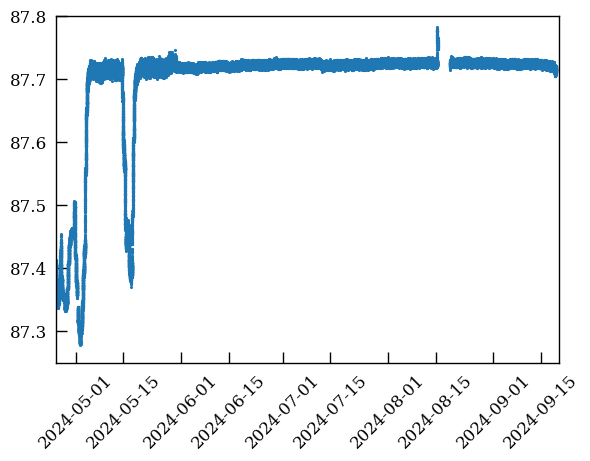

In [3]:
sensor2 = sensorClasses.Sensor(dataset=dataset, id=40012)
fig, axes = plt.subplots(1,1)
axes.plot(sensor2.data.index.values, sensor2.data.values, ".", label='Sensor 40001')
axes.set_xlim(datetime.datetime(2024, 4, 25), datetime.datetime(2024, 9, 20, 12))
axes.set_ylim(87.25,87.8)
axes.tick_params(axis='x', rotation=45)

# Before changing the power supply

Change made on 2024/09/20 12:03 by Xavier Pons. Power supply changed from shared with TPC CE to independent

In [4]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 4, 25)) & (dataset.data.index < datetime.datetime(2024, 9, 20, 12)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

# Effect of MUX current on temperature data

The MUX current affects the temperature measurement as the real intensity data is not being used to compute the resistance of the temperature sensors. In fact, it is assumed a 1 mA over every sensor independtly of the board they are connected to. Current fluctuations need to be properly addressed.

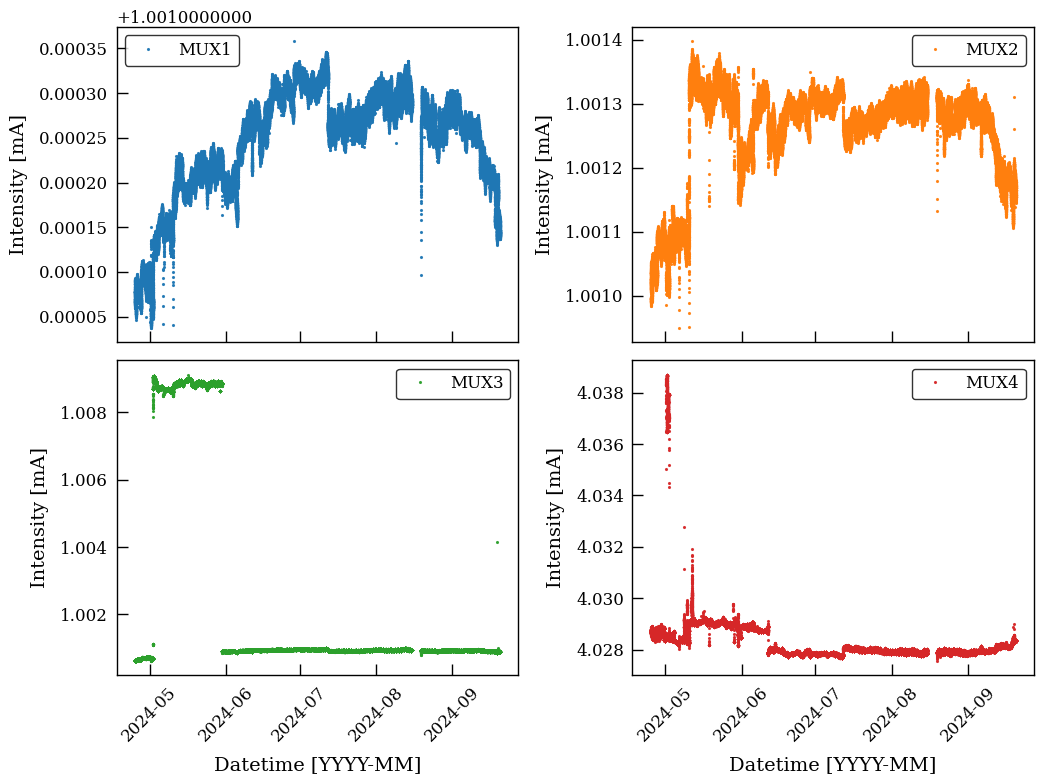

In [5]:
sensor = sensorClasses.Sensor(dataset=dataset, id=39630)
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

mux1.data = mux1.data.loc[(mux1.data>1)&(mux1.data<1.0014)]
mux2.data = mux2.data.loc[(mux2.data>1)&(mux2.data<1.0014)]
mux3.data = mux3.data.loc[(mux3.data>1)&(mux3.data<1.1)]
mux4.data = mux4.data.loc[(mux4.data>4)&(mux4.data<4.05)]
ambient = sensorClasses.Sensor(dataset=dataset, id=1037)
fig, ax = plt.subplots(2,2,figsize=(10.6, 8), sharex=True, sharey=False)
ax = ax.flatten()
ax[0].plot(mux1.data.index.values, mux1.data.values, ".", label="MUX1", color="tab:blue", alpha=0.9)
ax[1].plot(mux2.data.index.values, mux2.data.values, ".", label="MUX2", color="tab:orange", alpha=0.9)
ax[2].plot(mux3.data.index.values, mux3.data.values, ".", label="MUX3", color="tab:green", alpha=0.9)
ax[3].plot(mux4.data.index.values, mux4.data.values, ".", label="MUX4", color="tab:red", alpha=0.9)
# ax.plot(mux3.data.index.values, 1e6*(mux3.data.values - mux3.data.mean()) - 50, ".", label="MUX3", color="tab:green", alpha=0.9)
# ax.plot(mux4.data.index.values, 1e6*(4/mux4.data.values - 4/mux4.data.mean()) - 100, ".", label="MUX4", color="tab:red", alpha=0.9)
ax[2].tick_params(axis='x', rotation=45)
ax[3].tick_params(axis='x', rotation=45)
# ax2 = ax.twinx()
# ax2.set_ylabel("Ambient Temperature [ºC]")
# ax2.plot(ambient.data.index.values, ambient.data.values, ".", markersize=1.5, label="Ambient Temperature", color="black", alpha=0.2)
ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()
ax[0].set_ylabel("Intensity [mA]")
ax[1].set_ylabel("Intensity [mA]")
ax[2].set_ylabel("Intensity [mA]")
ax[3].set_ylabel("Intensity [mA]")
ax[2].set_xlabel("Datetime [YYYY-MM]")
ax[3].set_xlabel("Datetime [YYYY-MM]")
fig.tight_layout()

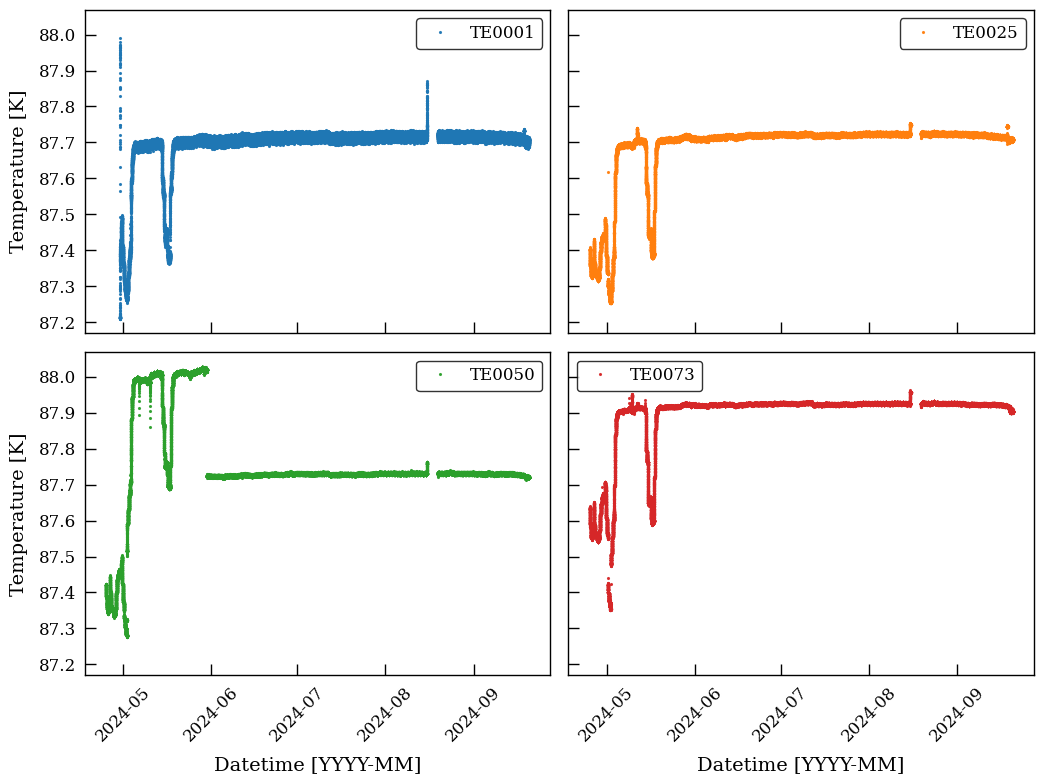

In [6]:
fig, ax = plt.subplots(2,2,figsize=(10.6, 8), sharex=True, sharey=True)
ax = ax.flatten()

dataset.data["TE0001"] = dataset.data["TE0001"].loc[(dataset.data["TE0001"] > 87) & (dataset.data["TE0001"] < 88)]
dataset.data["TE0025"] = dataset.data["TE0025"].loc[(dataset.data["TE0025"] > 87) & (dataset.data["TE0025"] < 88)]
dataset.data["TE0050"] = dataset.data["TE0050"].loc[(dataset.data["TE0050"] > 87) & (dataset.data["TE0050"] < 88.1)]
dataset.data["TE0073"] = dataset.data["TE0073"].loc[(dataset.data["TE0073"] > 86) & (dataset.data["TE0073"] < 90)]

ax[0].plot(dataset.data.index.values, dataset.data["TE0001"].values, ".", label="TE0001", color="tab:blue", alpha=0.9)
ax[1].plot(dataset.data.index.values, dataset.data["TE0025"].values, ".", label="TE0025", color="tab:orange", alpha=0.9)
ax[2].plot(dataset.data.index.values, dataset.data["TE0050"].values, ".", label="TE0050", color="tab:green", alpha=0.9)
ax[3].plot(dataset.data.index.values, dataset.data["TE0073"].values, ".", label="TE0073", color="tab:red", alpha=0.9)

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()

ax[2].tick_params(axis='x', rotation=45)
ax[3].tick_params(axis='x', rotation=45);

ax[0].set_ylabel("Temperature [K]")
ax[2].set_ylabel("Temperature [K]")
ax[2].set_xlabel("Datetime [YYYY-MM]")
ax[3].set_xlabel("Datetime [YYYY-MM]")
fig.tight_layout()

The effects of the current on the temperature data are in general smaller than the large-scale temperature structure observed over long-term periods. Nonetheless, the large current jump on MUX3 starting early May and finishing late May has a very clear effect on the temperature seen by the sensors on that board.

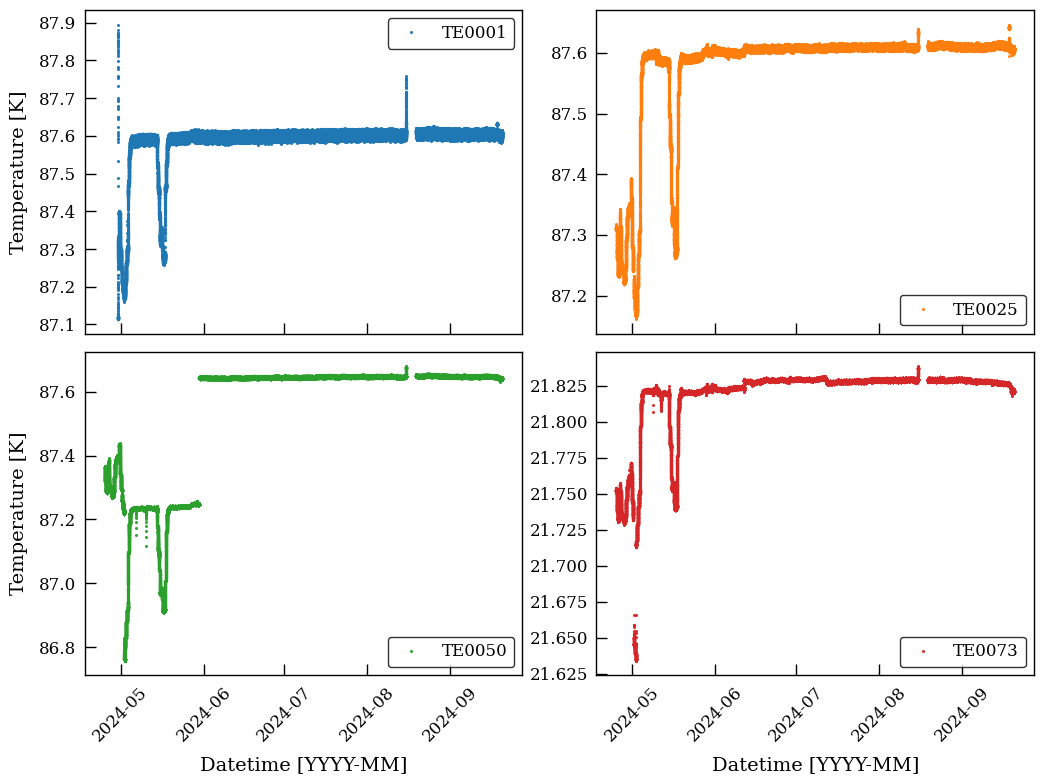

In [7]:
fig, ax = plt.subplots(2,2,figsize=(10.6, 8), sharex=True, sharey=False)
ax = ax.flatten()

ax[0].plot(dataset.data.index.values, (dataset.data["TE0001"]/mux1.data).values, ".", label="TE0001", color="tab:blue", alpha=0.9)
ax[1].plot(dataset.data.index.values, (dataset.data["TE0025"]/mux2.data).values, ".", label="TE0025", color="tab:orange", alpha=0.9)
ax[2].plot(dataset.data.index.values, (dataset.data["TE0050"]/mux3.data).values, ".", label="TE0050", color="tab:green", alpha=0.9)
ax[3].plot(dataset.data.index.values, (dataset.data["TE0073"]/mux4.data).values, ".", label="TE0073", color="tab:red", alpha=0.9)

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()

ax[2].tick_params(axis='x', rotation=45)
ax[3].tick_params(axis='x', rotation=45);

ax[0].set_ylabel("Temperature [K]")
ax[2].set_ylabel("Temperature [K]")
ax[2].set_xlabel("Datetime [YYYY-MM]")
ax[3].set_xlabel("Datetime [YYYY-MM]")
fig.tight_layout()

Now, restrict the data within the time window where the large-scale temperature fluctuations are not present to create figures where the effect of the current correction is seen. The chosen time window will be from 06/01 to 08/01.

In [8]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 6, 12)) & (dataset.data.index < datetime.datetime(2024, 8, 1)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

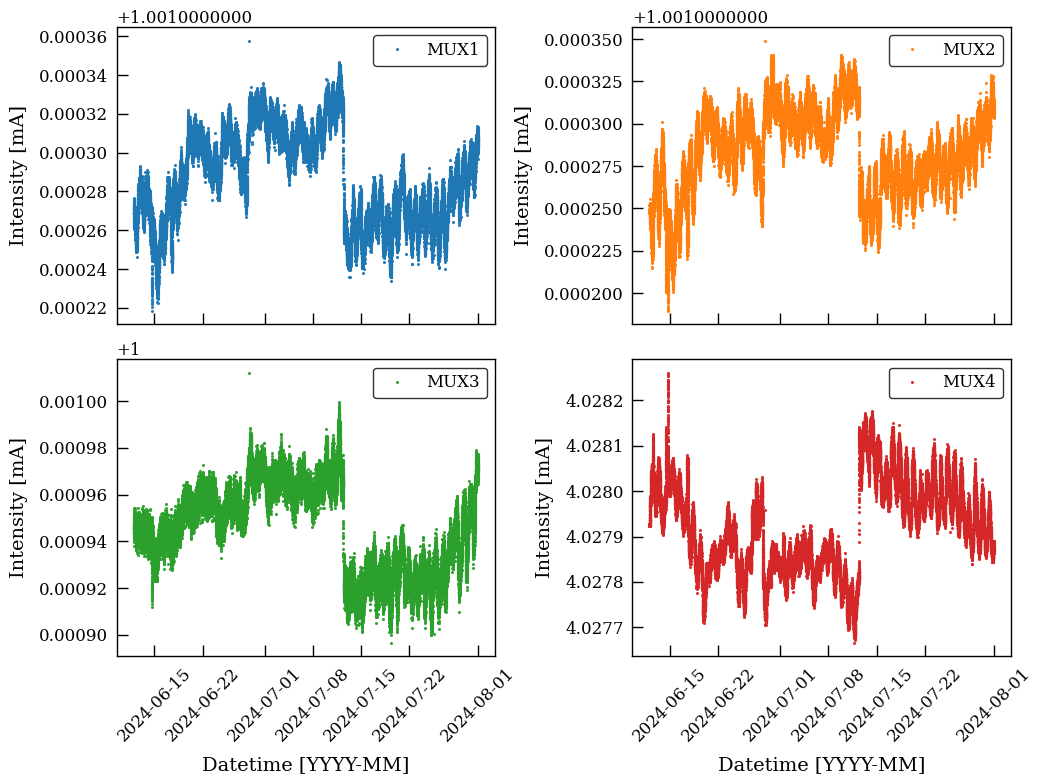

In [9]:
sensor = sensorClasses.Sensor(dataset=dataset, id=39630)
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

mux1.data = mux1.data.loc[(mux1.data>1)&(mux1.data<1.0014)]
mux2.data = mux2.data.loc[(mux2.data>1)&(mux2.data<1.0014)]
mux3.data = mux3.data.loc[(mux3.data>1)&(mux3.data<1.1)]
mux4.data = mux4.data.loc[(mux4.data>4)&(mux4.data<4.05)]
ambient = sensorClasses.Sensor(dataset=dataset, id=1037)
fig, ax = plt.subplots(2,2,figsize=(10.6, 8), sharex=True, sharey=False)
ax = ax.flatten()
ax[0].plot(mux1.data.index.values, mux1.data.values, ".", label="MUX1", color="tab:blue", alpha=0.9)
ax[1].plot(mux2.data.index.values, mux2.data.values, ".", label="MUX2", color="tab:orange", alpha=0.9)
ax[2].plot(mux3.data.index.values, mux3.data.values, ".", label="MUX3", color="tab:green", alpha=0.9)
ax[3].plot(mux4.data.index.values, mux4.data.values, ".", label="MUX4", color="tab:red", alpha=0.9)
# ax.plot(mux3.data.index.values, 1e6*(mux3.data.values - mux3.data.mean()) - 50, ".", label="MUX3", color="tab:green", alpha=0.9)
# ax.plot(mux4.data.index.values, 1e6*(4/mux4.data.values - 4/mux4.data.mean()) - 100, ".", label="MUX4", color="tab:red", alpha=0.9)
ax[2].tick_params(axis='x', rotation=45)
ax[3].tick_params(axis='x', rotation=45)
# ax2 = ax.twinx()
# ax2.set_ylabel("Ambient Temperature [ºC]")
# ax2.plot(ambient.data.index.values, ambient.data.values, ".", markersize=1.5, label="Ambient Temperature", color="black", alpha=0.2)
ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()
ax[0].set_ylabel("Intensity [mA]")
ax[1].set_ylabel("Intensity [mA]")
ax[2].set_ylabel("Intensity [mA]")
ax[3].set_ylabel("Intensity [mA]")
ax[2].set_xlabel("Datetime [YYYY-MM]")
ax[3].set_xlabel("Datetime [YYYY-MM]")
fig.tight_layout()

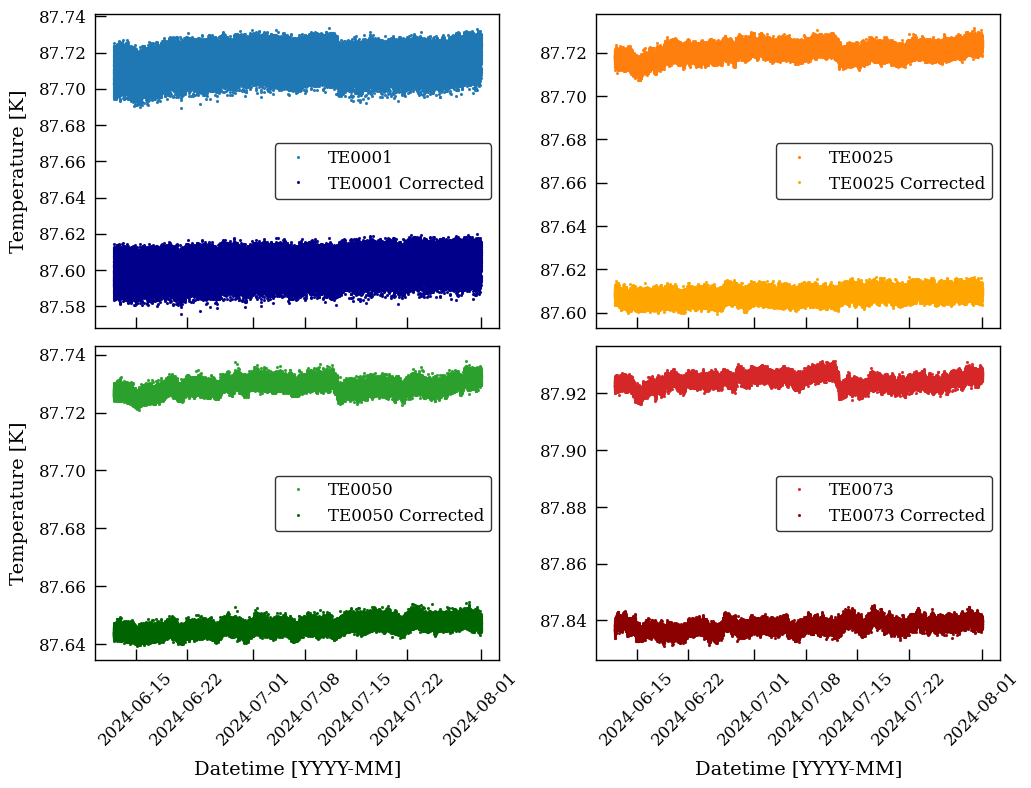

In [10]:
fig, ax = plt.subplots(2,2,figsize=(10.6, 8), sharex=True, sharey=False)
ax = ax.flatten()

mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

ax[0].plot(dataset.data.index.values, dataset.data["TE0001"].values, ".", label="TE0001", color="tab:blue", alpha=0.9)
ax[1].plot(dataset.data.index.values, dataset.data["TE0025"].values, ".", label="TE0025", color="tab:orange", alpha=0.9)
ax[2].plot(dataset.data.index.values, dataset.data["TE0050"].values, ".", label="TE0050", color="tab:green", alpha=0.9)
ax[3].plot(dataset.data.index.values, dataset.data["TE0073"].values, ".", label="TE0073", color="tab:red", alpha=0.9)

ax[0].plot(dataset.data.index.values, (dataset.data["TE0001"]/mux1.data).values, ".", label="TE0001 Corrected", color="darkblue", alpha=0.9)
ax[1].plot(dataset.data.index.values, (dataset.data["TE0025"]/mux2.data).values, ".", label="TE0025 Corrected", color="orange", alpha=0.9)
ax[2].plot(dataset.data.index.values, (dataset.data["TE0050"]/mux3.data).values, ".", label="TE0050 Corrected", color="darkgreen", alpha=0.9)
ax[3].plot(dataset.data.index.values, (dataset.data["TE0073"]*mux4.data/4).values - 0.7, ".", label="TE0073 Corrected", color="darkred", alpha=0.9)

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()

ax[2].tick_params(axis='x', rotation=45)
ax[3].tick_params(axis='x', rotation=45);

ax[0].set_ylabel("Temperature [K]")
ax[2].set_ylabel("Temperature [K]")
ax[2].set_xlabel("Datetime [YYYY-MM]")
ax[3].set_xlabel("Datetime [YYYY-MM]")
fig.tight_layout()

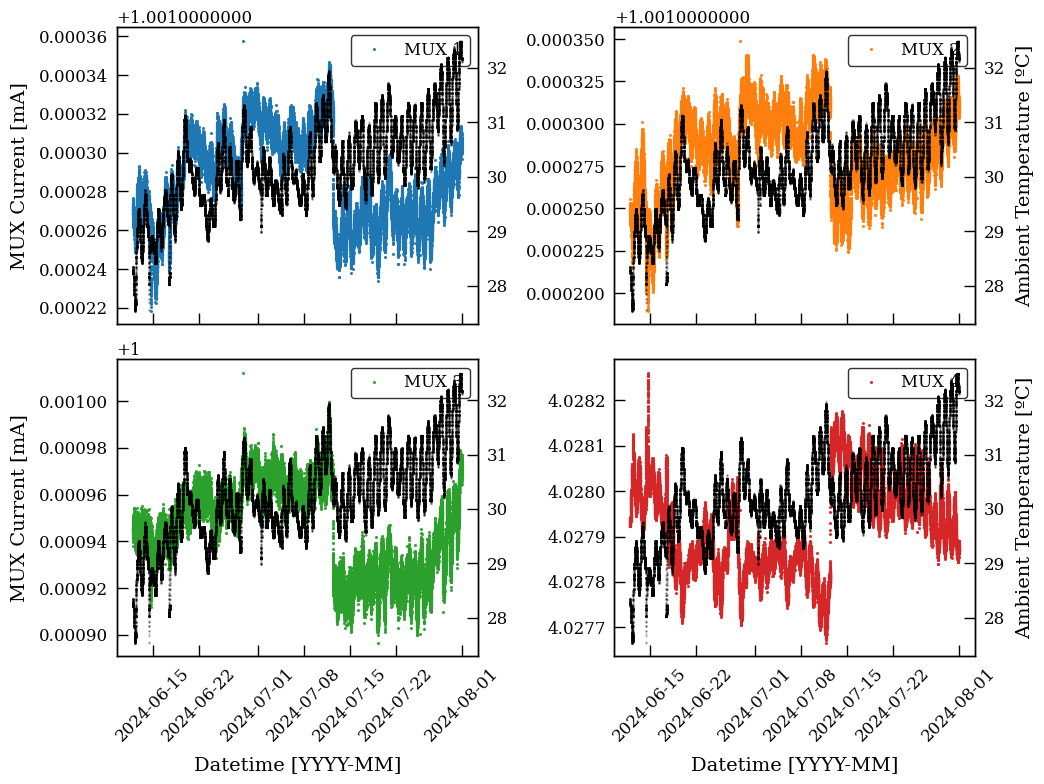

In [18]:
fig, ax = plt.subplots(2,2,figsize=(10.6, 8), sharex=True, sharey=False)
ax = ax.flatten()

mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

ax[0].plot(mux1.data.index.values, mux1.data.values, ".", label="MUX 1", color="tab:blue", alpha=0.9)
ax[1].plot(mux2.data.index.values, mux2.data.values, ".", label="MUX 2", color="tab:orange", alpha=0.9)
ax[2].plot(mux3.data.index.values, mux3.data.values, ".", label="MUX 3", color="tab:green", alpha=0.9)
ax[3].plot(mux4.data.index.values, mux4.data.values, ".", label="MUX 4", color="tab:red", alpha=0.9)

# ax[0].plot(dataset.data.index.values, (dataset.data["TE0024"]/mux1.data).values, ".", label="TE0024 Corrected", color="darkblue", alpha=0.9)
# ax[1].plot(dataset.data.index.values, (dataset.data["TE0025"]/mux2.data).values, ".", label="TE0025 Corrected", color="orange", alpha=0.9)
# ax[2].plot(dataset.data.index.values, (dataset.data["TE0050"]/mux3.data).values, ".", label="TE0050 Corrected", color="darkgreen", alpha=0.9)
# ax[3].plot(dataset.data.index.values, (dataset.data["TE0073"]*mux4.data/4).values - 0.7, ".", label="TE0073 Corrected", color="darkred", alpha=0.9)

ax1 = ax[0].twinx()
ax1.plot(ambient.data.index.values, ambient.data.values, ".", markersize=1.5, label="Ambient Temperature", color="black", alpha=0.2)
# ax1.set_ylabel("Ambient Temperature [ºC]")
ax2 = ax[1].twinx()
ax2.plot(ambient.data.index.values, ambient.data.values, ".", markersize=1.5, label="Ambient Temperature", color="black", alpha=0.2)
ax2.set_ylabel("Ambient Temperature [ºC]")
ax3 = ax[2].twinx()
ax3.plot(ambient.data.index.values, ambient.data.values, ".", markersize=1.5, label="Ambient Temperature", color="black", alpha=0.2)
# ax3.set_ylabel("Ambient Temperature [ºC]")
ax4 = ax[3].twinx()
ax4.plot(ambient.data.index.values, ambient.data.values, ".", markersize=1.5, label="Ambient Temperature", color="black", alpha=0.2)
ax4.set_ylabel("Ambient Temperature [ºC]")

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()

ax[2].tick_params(axis='x', rotation=45)
ax[3].tick_params(axis='x', rotation=45);

ax[0].set_ylabel("MUX Current [mA]")
ax[2].set_ylabel("MUX Current [mA]")
ax[2].set_xlabel("Datetime [YYYY-MM]")
ax[3].set_xlabel("Datetime [YYYY-MM]")
fig.tight_layout()

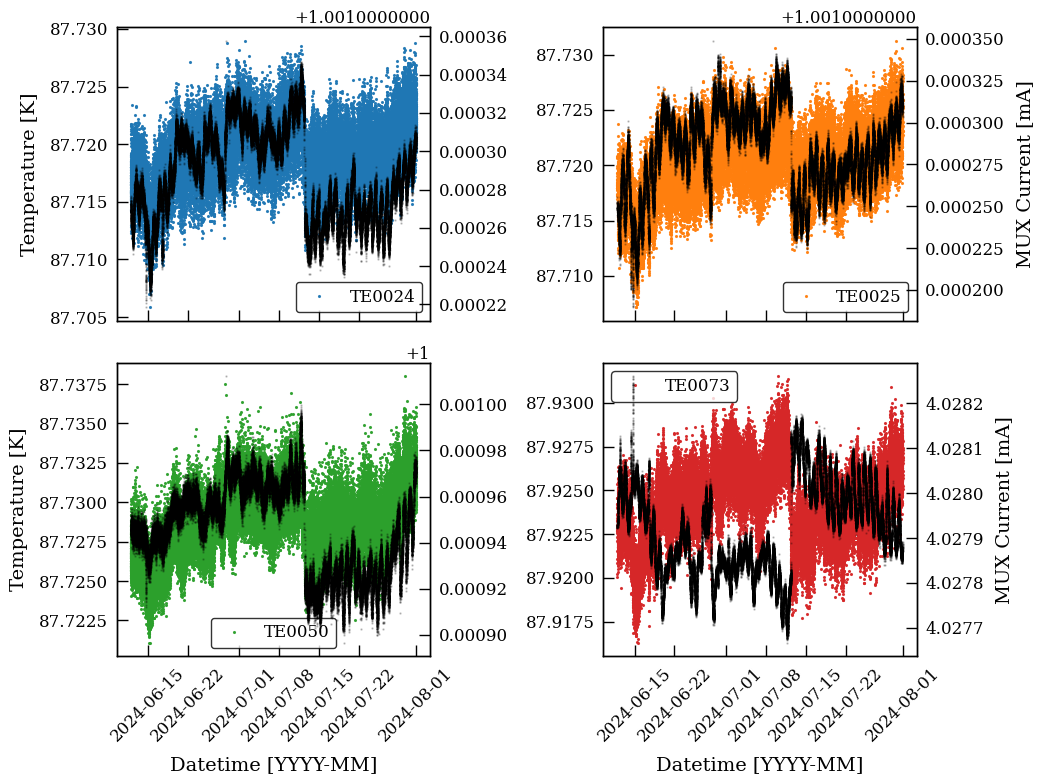

In [19]:
fig, ax = plt.subplots(2,2,figsize=(10.6, 8), sharex=True, sharey=False)
ax = ax.flatten()

mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

ax[0].plot(dataset.data.index.values, dataset.data["TE0024"].values, ".", label="TE0024", color="tab:blue", alpha=0.9)
ax[1].plot(dataset.data.index.values, dataset.data["TE0025"].values, ".", label="TE0025", color="tab:orange", alpha=0.9)
ax[2].plot(dataset.data.index.values, dataset.data["TE0050"].values, ".", label="TE0050", color="tab:green", alpha=0.9)
ax[3].plot(dataset.data.index.values, dataset.data["TE0073"].values, ".", label="TE0073", color="tab:red", alpha=0.9)

# ax[0].plot(dataset.data.index.values, (dataset.data["TE0024"]/mux1.data).values, ".", label="TE0024 Corrected", color="darkblue", alpha=0.9)
# ax[1].plot(dataset.data.index.values, (dataset.data["TE0025"]/mux2.data).values, ".", label="TE0025 Corrected", color="orange", alpha=0.9)
# ax[2].plot(dataset.data.index.values, (dataset.data["TE0050"]/mux3.data).values, ".", label="TE0050 Corrected", color="darkgreen", alpha=0.9)
# ax[3].plot(dataset.data.index.values, (dataset.data["TE0073"]*mux4.data/4).values - 0.7, ".", label="TE0073 Corrected", color="darkred", alpha=0.9)

ax1 = ax[0].twinx()
ax1.plot(mux1.data.index.values, mux1.data.values, ".", markersize=1.5, label="Ambient Temperature", color="black", alpha=0.2)
# ax1.set_ylabel("Muc Current [mA]")
ax2 = ax[1].twinx()
ax2.plot(mux2.data.index.values, mux2.data.values, ".", markersize=1.5, label="Ambient Temperature", color="black", alpha=0.2)
ax2.set_ylabel("MUX Current [mA]")
ax3 = ax[2].twinx()
ax3.plot(mux3.data.index.values, mux3.data.values, ".", markersize=1.5, label="Ambient Temperature", color="black", alpha=0.2)
# ax3.set_ylabel("MUX Current [mA]")
ax4 = ax[3].twinx()
ax4.plot(mux4.data.index.values, mux4.data.values, ".", markersize=1.5, label="Ambient Temperature", color="black", alpha=0.2)
ax4.set_ylabel("MUX Current [mA]")

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()

ax[2].tick_params(axis='x', rotation=45)
ax[3].tick_params(axis='x', rotation=45);

ax[0].set_ylabel("Temperature [K]")
ax[2].set_ylabel("Temperature [K]")
ax[2].set_xlabel("Datetime [YYYY-MM]")
ax[3].set_xlabel("Datetime [YYYY-MM]")
fig.tight_layout()

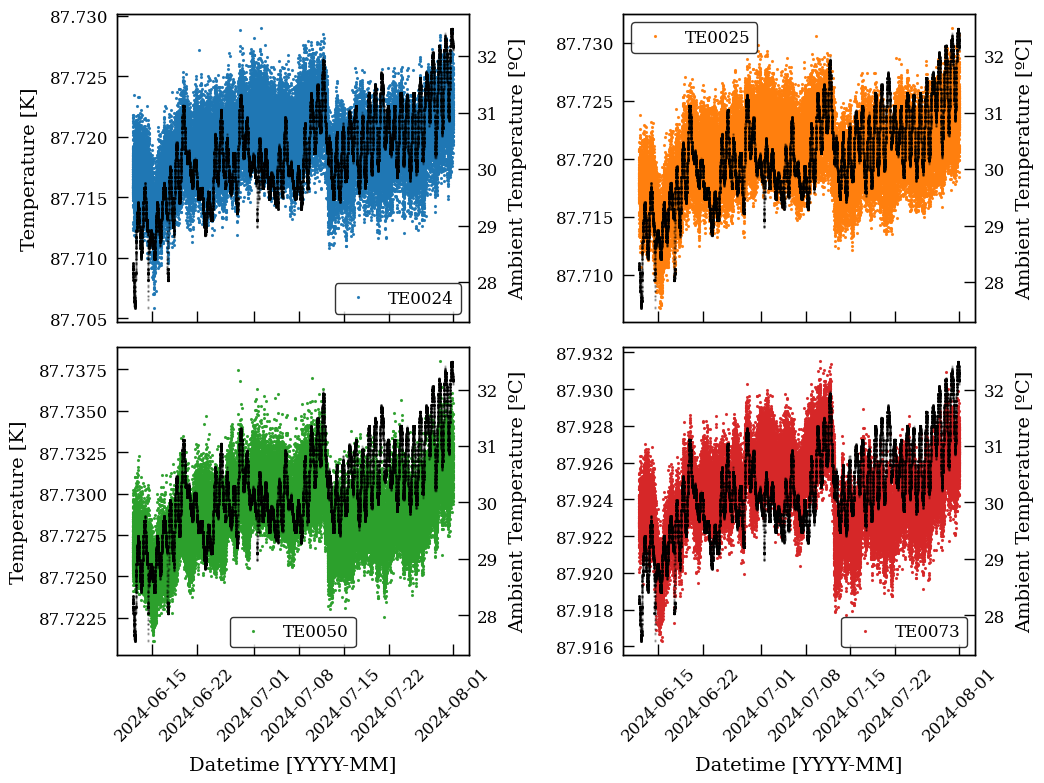

In [11]:
fig, ax = plt.subplots(2,2,figsize=(10.6, 8), sharex=True, sharey=False)
ax = ax.flatten()

mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

ax[0].plot(dataset.data.index.values, dataset.data["TE0024"].values, ".", label="TE0024", color="tab:blue", alpha=0.9)
ax[1].plot(dataset.data.index.values, dataset.data["TE0025"].values, ".", label="TE0025", color="tab:orange", alpha=0.9)
ax[2].plot(dataset.data.index.values, dataset.data["TE0050"].values, ".", label="TE0050", color="tab:green", alpha=0.9)
ax[3].plot(dataset.data.index.values, dataset.data["TE0073"].values, ".", label="TE0073", color="tab:red", alpha=0.9)

# ax[0].plot(dataset.data.index.values, (dataset.data["TE0024"]/mux1.data).values, ".", label="TE0024 Corrected", color="darkblue", alpha=0.9)
# ax[1].plot(dataset.data.index.values, (dataset.data["TE0025"]/mux2.data).values, ".", label="TE0025 Corrected", color="orange", alpha=0.9)
# ax[2].plot(dataset.data.index.values, (dataset.data["TE0050"]/mux3.data).values, ".", label="TE0050 Corrected", color="darkgreen", alpha=0.9)
# ax[3].plot(dataset.data.index.values, (dataset.data["TE0073"]*mux4.data/4).values - 0.7, ".", label="TE0073 Corrected", color="darkred", alpha=0.9)

ax1 = ax[0].twinx()
ax1.plot(ambient.data.index.values, ambient.data.values, ".", markersize=1.5, label="Ambient Temperature", color="black", alpha=0.2)
ax1.set_ylabel("Ambient Temperature [ºC]")
ax2 = ax[1].twinx()
ax2.plot(ambient.data.index.values, ambient.data.values, ".", markersize=1.5, label="Ambient Temperature", color="black", alpha=0.2)
ax2.set_ylabel("Ambient Temperature [ºC]")
ax3 = ax[2].twinx()
ax3.plot(ambient.data.index.values, ambient.data.values, ".", markersize=1.5, label="Ambient Temperature", color="black", alpha=0.2)
ax3.set_ylabel("Ambient Temperature [ºC]")
ax4 = ax[3].twinx()
ax4.plot(ambient.data.index.values, ambient.data.values, ".", markersize=1.5, label="Ambient Temperature", color="black", alpha=0.2)
ax4.set_ylabel("Ambient Temperature [ºC]")

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()

ax[2].tick_params(axis='x', rotation=45)
ax[3].tick_params(axis='x', rotation=45);

ax[0].set_ylabel("Temperature [K]")
ax[2].set_ylabel("Temperature [K]")
ax[2].set_xlabel("Datetime [YYYY-MM]")
ax[3].set_xlabel("Datetime [YYYY-MM]")
fig.tight_layout()

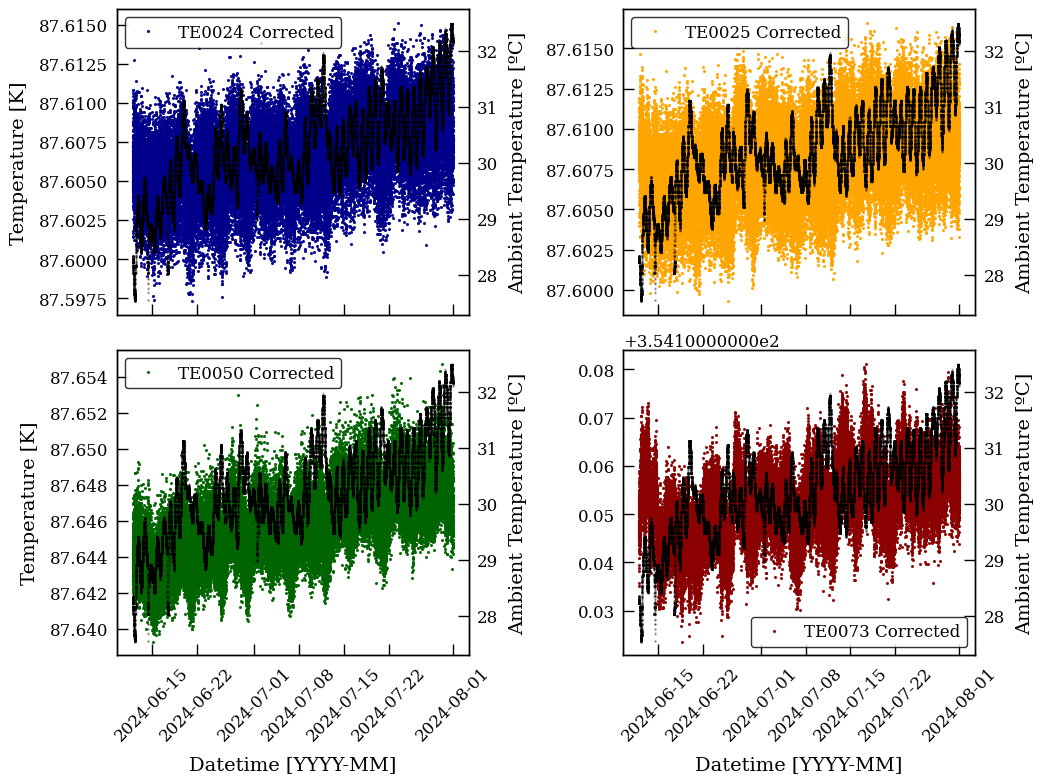

In [13]:
fig, ax = plt.subplots(2,2,figsize=(10.6, 8), sharex=True, sharey=False)
ax = ax.flatten()

mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

# ax[0].plot(dataset.data.index.values, dataset.data["TE0001"].values, ".", label="TE0001", color="tab:blue", alpha=0.9)
# ax[1].plot(dataset.data.index.values, dataset.data["TE0025"].values, ".", label="TE0025", color="tab:orange", alpha=0.9)
# ax[2].plot(dataset.data.index.values, dataset.data["TE0050"].values, ".", label="TE0050", color="tab:green", alpha=0.9)
# ax[3].plot(dataset.data.index.values, dataset.data["TE0073"].values, ".", label="TE0073", color="tab:red", alpha=0.9)

ax[0].plot(dataset.data.index.values, (dataset.data["TE0024"]/mux1.data).values, ".", label="TE0024 Corrected", color="darkblue", alpha=0.9)
ax[1].plot(dataset.data.index.values, (dataset.data["TE0025"]/mux2.data).values, ".", label="TE0025 Corrected", color="orange", alpha=0.9)
ax[2].plot(dataset.data.index.values, (dataset.data["TE0050"]/mux3.data).values, ".", label="TE0050 Corrected", color="darkgreen", alpha=0.9)
ax[3].plot(dataset.data.index.values, (dataset.data["TE0073"]*mux4.data).values, ".", label="TE0073 Corrected", color="darkred", alpha=0.9)

ax1 = ax[0].twinx()
ax1.plot(ambient.data.index.values, ambient.data.values, ".", markersize=1.5, label="Ambient Temperature", color="black", alpha=0.2)
ax1.set_ylabel("Ambient Temperature [ºC]")
ax2 = ax[1].twinx()
ax2.plot(ambient.data.index.values, ambient.data.values, ".", markersize=1.5, label="Ambient Temperature", color="black", alpha=0.2)
ax2.set_ylabel("Ambient Temperature [ºC]")
ax3 = ax[2].twinx()
ax3.plot(ambient.data.index.values, ambient.data.values, ".", markersize=1.5, label="Ambient Temperature", color="black", alpha=0.2)
ax3.set_ylabel("Ambient Temperature [ºC]")
ax4 = ax[3].twinx()
ax4.plot(ambient.data.index.values, ambient.data.values, ".", markersize=1.5, label="Ambient Temperature", color="black", alpha=0.2)
ax4.set_ylabel("Ambient Temperature [ºC]")

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()

ax[2].tick_params(axis='x', rotation=45)
ax[3].tick_params(axis='x', rotation=45);

ax[0].set_ylabel("Temperature [K]")
ax[2].set_ylabel("Temperature [K]")
ax[2].set_xlabel("Datetime [YYYY-MM]")
ax[3].set_xlabel("Datetime [YYYY-MM]")
fig.tight_layout()

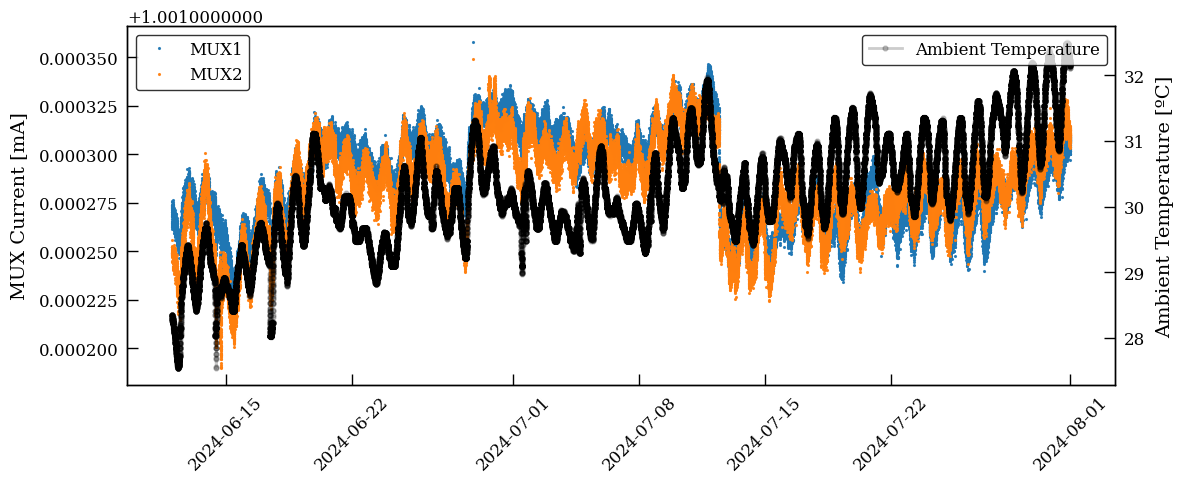

In [33]:
sensor = sensorClasses.Sensor(dataset=dataset, id=39630)
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

mux1.data = mux1.data.loc[(mux1.data>1)&(mux1.data<1.0014)]
mux2.data = mux2.data.loc[(mux2.data>1)&(mux2.data<1.0014)]
mux3.data = mux3.data.loc[(mux3.data>1)&(mux3.data<1.1)]
mux4.data = mux4.data.loc[(mux4.data>4)&(mux4.data<4.05)]
ambient = sensorClasses.Sensor(dataset=dataset, id=1037)
ambient.data = ambient.data.dropna()
ambient.data = ambient.data.loc[(ambient.data>23.5)]
fig, ax = plt.subplots(1,1,figsize=(12, 5))
ax.set_ylabel("MUX Current [mA]")
ax.plot(mux1.data.index.values, mux1.data.values, ".", label="MUX1", color="tab:blue", alpha=0.9)
ax.plot(mux2.data.index.values, mux2.data.values, ".", label="MUX2", color="tab:orange", alpha=0.9)
# ax.plot(mux3.data.index.values, mux3.data.values, ".", label="MUX3", color="tab:green", alpha=0.9)
# ax.plot(mux3.data.index.values, 1e6*(mux3.data.values - mux3.data.mean()) - 50, ".", label="MUX3", color="tab:green", alpha=0.9)
# ax.plot(mux4.data.index.values, 1e6*(4/mux4.data.values - 4/mux4.data.mean()) - 100, ".", label="MUX4", color="tab:red", alpha=0.9)
ax.tick_params(axis='x', rotation=45)
ax2 = ax.twinx()
ax2.set_ylabel("Ambient Temperature [ºC]")
ax2.plot(ambient.data.index.values, ambient.data.values, "-o", markersize=3.5, label="Ambient Temperature", color="black", alpha=0.2)
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
fig.tight_layout()

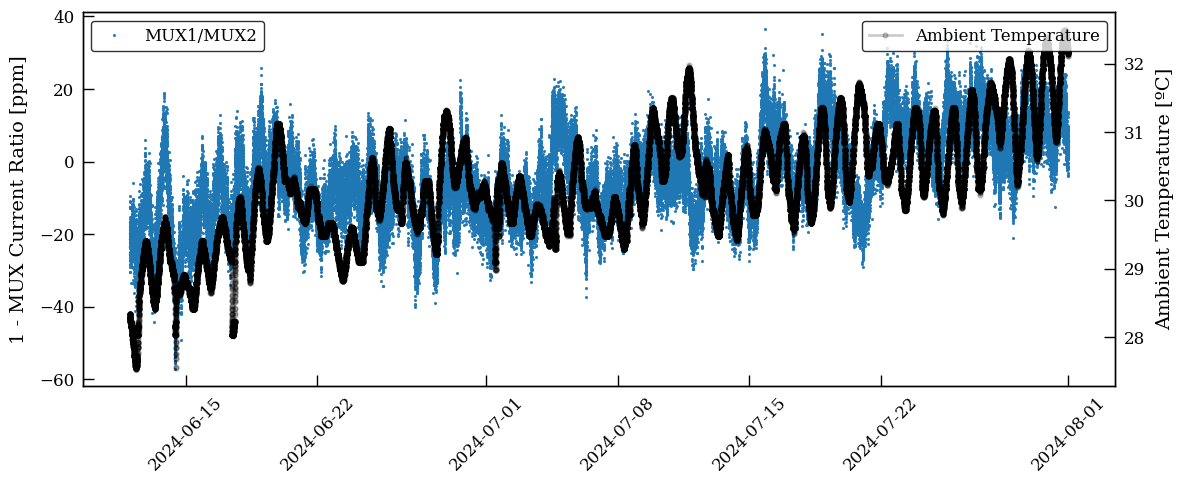

In [28]:
sensor = sensorClasses.Sensor(dataset=dataset, id=39630)
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

mux1.data = mux1.data.loc[(mux1.data>1)&(mux1.data<1.0014)]
mux2.data = mux2.data.loc[(mux2.data>1)&(mux2.data<1.0014)]
mux3.data = mux3.data.loc[(mux3.data>1)&(mux3.data<1.1)]
mux4.data = mux4.data.loc[(mux4.data>4)&(mux4.data<4.05)]
ambient = sensorClasses.Sensor(dataset=dataset, id=1037)
ambient.data = ambient.data.dropna()
ambient.data = ambient.data.loc[(ambient.data>23.5)]
fig, ax = plt.subplots(1,1,figsize=(12, 5))
ax.set_ylabel("1 - MUX Current Ratio [ppm]")
ax.plot(mux1.data.index.values, 1e6*(1 - (mux1.data/mux2.data).values), ".", label="MUX1/MUX2", color="tab:blue", alpha=0.9)
# ax.plot(mux2.data.index.values, mux2.data.values, ".", label="MUX2", color="tab:orange", alpha=0.9)
# ax.plot(mux3.data.index.values, mux3.data.values, ".", label="MUX3", color="tab:green", alpha=0.9)
# ax.plot(mux3.data.index.values, 1e6*(mux3.data.values - mux3.data.mean()) - 50, ".", label="MUX3", color="tab:green", alpha=0.9)
# ax.plot(mux4.data.index.values, 1e6*(4/mux4.data.values - 4/mux4.data.mean()) - 100, ".", label="MUX4", color="tab:red", alpha=0.9)
ax.tick_params(axis='x', rotation=45)
ax2 = ax.twinx()
ax2.set_ylabel("Ambient Temperature [ºC]")
ax2.plot(ambient.data.index.values, ambient.data.values, "-o", markersize=3.5, label="Ambient Temperature", color="black", alpha=0.2)
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
fig.tight_layout()

Fitted parameters: <ValueView A=8.175362834403675 B=-251.16661986665622>
Parameter errors: <ErrorView A=0.0045150121726793896 B=0.13647036426513254>
Covariance matrix:
 ┌───┬─────────────────────┐
│   │         A         B │
├───┼─────────────────────┤
│ A │  2.04e-05 -0.616e-3 │
│ B │ -0.616e-3    0.0186 │
└───┴─────────────────────┘


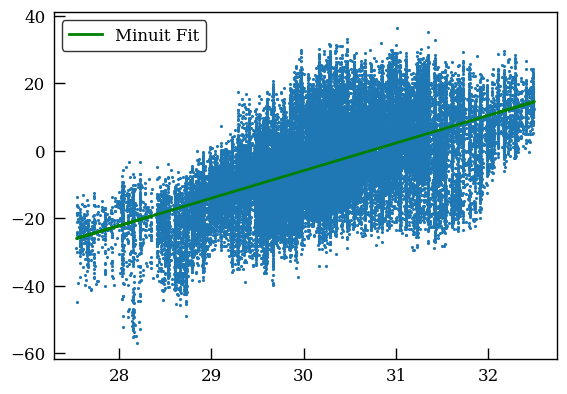

In [42]:
from iminuit import Minuit
from iminuit.cost import LeastSquares

x = ambient.data.loc[common_idx].values
x_idx = ambient.data.loc[common_idx].index
y = (1 - (mux1.data.loc[common_idx] / mux2.data.loc[common_idx]).values) * 1e6
y_idx = mux1.data.loc[common_idx].index

def line(x, A, B):
    return A * x + B

least_squares = LeastSquares(x, y, np.ones_like(y), line)
m = Minuit(least_squares, A=1, B=0)
m.migrad()

print("Fitted parameters:", m.values)
print("Parameter errors:", m.errors)
print("Covariance matrix:\n", m.covariance)

plt.plot(x, y, ".")
plt.plot(x, line(x, *m.values), label="Minuit Fit", color="green")
plt.legend()

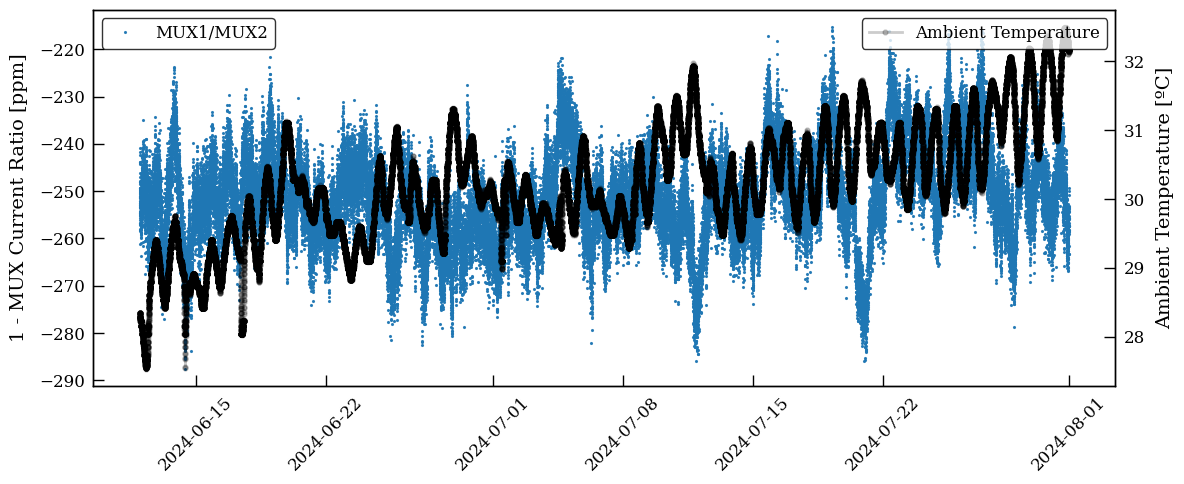

In [48]:
sensor = sensorClasses.Sensor(dataset=dataset, id=39630)
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

mux1.data = mux1.data.loc[(mux1.data>1)&(mux1.data<1.0014)]
mux2.data = mux2.data.loc[(mux2.data>1)&(mux2.data<1.0014)]
mux3.data = mux3.data.loc[(mux3.data>1)&(mux3.data<1.1)]
mux4.data = mux4.data.loc[(mux4.data>4)&(mux4.data<4.05)]
ambient = sensorClasses.Sensor(dataset=dataset, id=1037)
ambient.data = ambient.data.dropna()
ambient.data = ambient.data.loc[(ambient.data>23.5)]
fig, ax = plt.subplots(1,1,figsize=(12, 5))
ax.set_ylabel("1 - MUX Current Ratio [ppm]")
ax.plot(y_idx.values, y - x*m.values["A"], ".", label="MUX1/MUX2", color="tab:blue", alpha=0.9)
# ax.plot(mux2.data.index.values, mux2.data.values, ".", label="MUX2", color="tab:orange", alpha=0.9)
# ax.plot(mux3.data.index.values, mux3.data.values, ".", label="MUX3", color="tab:green", alpha=0.9)
# ax.plot(mux3.data.index.values, 1e6*(mux3.data.values - mux3.data.mean()) - 50, ".", label="MUX3", color="tab:green", alpha=0.9)
# ax.plot(mux4.data.index.values, 1e6*(4/mux4.data.values - 4/mux4.data.mean()) - 100, ".", label="MUX4", color="tab:red", alpha=0.9)
ax.tick_params(axis='x', rotation=45)
ax2 = ax.twinx()
ax2.set_ylabel("Ambient Temperature [ºC]")
ax2.plot(ambient.data.index.values, ambient.data.values, "-o", markersize=3.5, label="Ambient Temperature", color="black", alpha=0.2)
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
fig.tight_layout()

# After changing the power supply

Change made on 2024/09/20 12:03 by Xavier Pons. Power supply changed from shared with TPC CE to independent

In [44]:
dataset = baseClasses.Data()

In [45]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 9, 20, 12)) & (dataset.data.index < datetime.datetime(2025, 1, 1)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

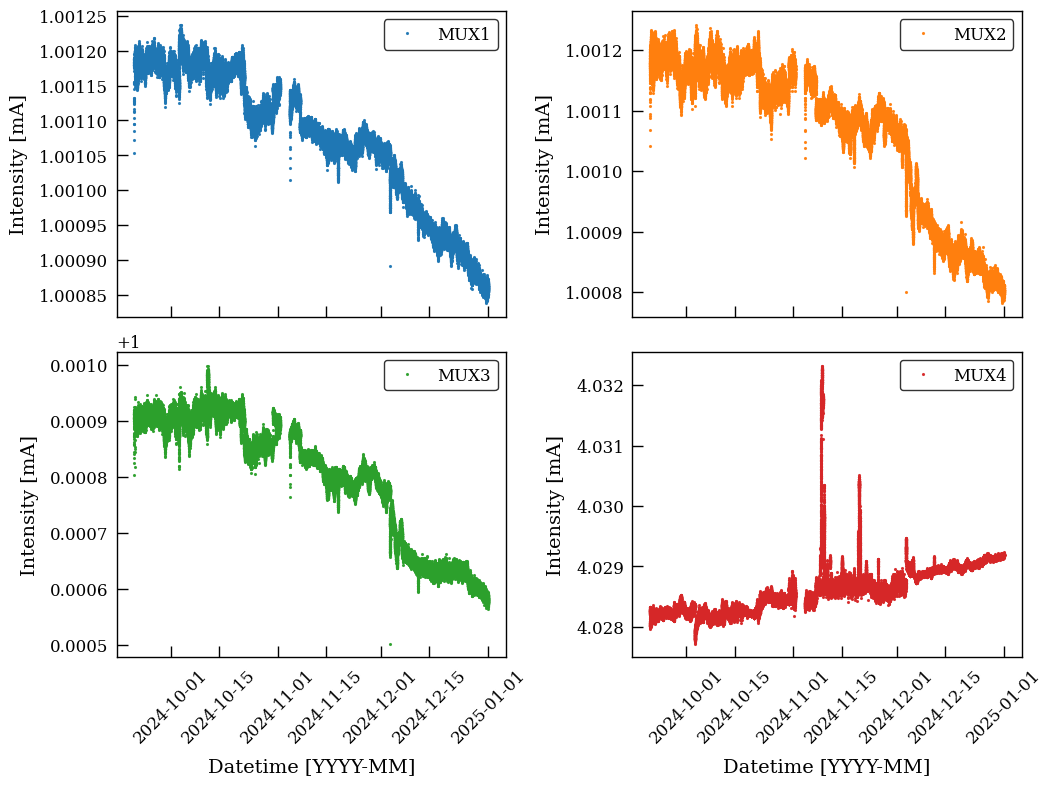

In [46]:
sensor = sensorClasses.Sensor(dataset=dataset, id=39630)
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

mux1.data = mux1.data.loc[(mux1.data>1)&(mux1.data<1.0014)]
mux2.data = mux2.data.loc[(mux2.data>1)&(mux2.data<1.0014)]
mux3.data = mux3.data.loc[(mux3.data>1)&(mux3.data<1.1)]
mux4.data = mux4.data.loc[(mux4.data>4)&(mux4.data<4.05)]
ambient = sensorClasses.Sensor(dataset=dataset, id=1037)
fig, ax = plt.subplots(2,2,figsize=(10.6, 8), sharex=True, sharey=False)
ax = ax.flatten()
ax[0].plot(mux1.data.index.values, mux1.data.values, ".", label="MUX1", color="tab:blue", alpha=0.9)
ax[1].plot(mux2.data.index.values, mux2.data.values, ".", label="MUX2", color="tab:orange", alpha=0.9)
ax[2].plot(mux3.data.index.values, mux3.data.values, ".", label="MUX3", color="tab:green", alpha=0.9)
ax[3].plot(mux4.data.index.values, mux4.data.values, ".", label="MUX4", color="tab:red", alpha=0.9)
# ax.plot(mux3.data.index.values, 1e6*(mux3.data.values - mux3.data.mean()) - 50, ".", label="MUX3", color="tab:green", alpha=0.9)
# ax.plot(mux4.data.index.values, 1e6*(4/mux4.data.values - 4/mux4.data.mean()) - 100, ".", label="MUX4", color="tab:red", alpha=0.9)
ax[2].tick_params(axis='x', rotation=45)
ax[3].tick_params(axis='x', rotation=45)
# ax2 = ax.twinx()
# ax2.set_ylabel("Ambient Temperature [ºC]")
# ax2.plot(ambient.data.index.values, ambient.data.values, ".", markersize=1.5, label="Ambient Temperature", color="black", alpha=0.2)
ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()
ax[0].set_ylabel("Intensity [mA]")
ax[1].set_ylabel("Intensity [mA]")
ax[2].set_ylabel("Intensity [mA]")
ax[3].set_ylabel("Intensity [mA]")
ax[2].set_xlabel("Datetime [YYYY-MM]")
ax[3].set_xlabel("Datetime [YYYY-MM]")
fig.tight_layout()

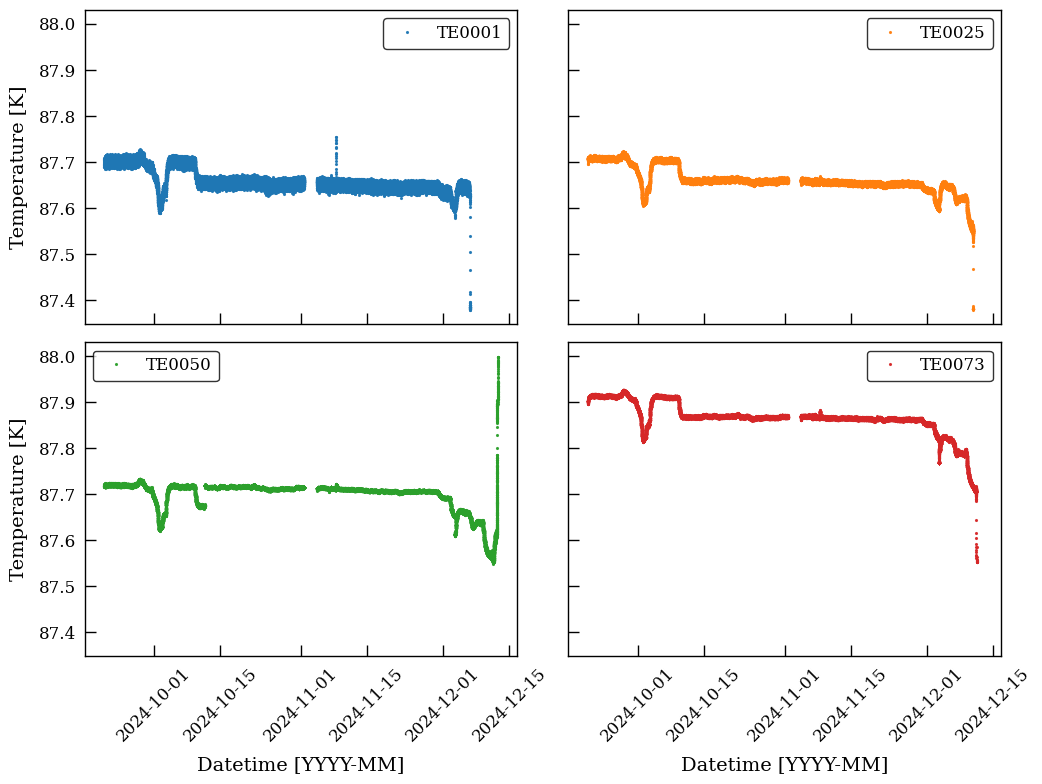

In [47]:
fig, ax = plt.subplots(2,2,figsize=(10.6, 8), sharex=True, sharey=True)
ax = ax.flatten()

dataset.data["TE0001"] = dataset.data["TE0001"].loc[(dataset.data["TE0001"] > 87) & (dataset.data["TE0001"] < 88)]
dataset.data["TE0025"] = dataset.data["TE0025"].loc[(dataset.data["TE0025"] > 87) & (dataset.data["TE0025"] < 88)]
dataset.data["TE0050"] = dataset.data["TE0050"].loc[(dataset.data["TE0050"] > 87) & (dataset.data["TE0050"] < 88)]
dataset.data["TE0073"] = dataset.data["TE0073"].loc[(dataset.data["TE0073"] > 86) & (dataset.data["TE0073"] < 88)]

ax[0].plot(dataset.data.index.values, dataset.data["TE0001"].values, ".", label="TE0001", color="tab:blue", alpha=0.9)
ax[1].plot(dataset.data.index.values, dataset.data["TE0025"].values, ".", label="TE0025", color="tab:orange", alpha=0.9)
ax[2].plot(dataset.data.index.values, dataset.data["TE0050"].values, ".", label="TE0050", color="tab:green", alpha=0.9)
ax[3].plot(dataset.data.index.values, dataset.data["TE0073"].values, ".", label="TE0073", color="tab:red", alpha=0.9)

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()

ax[2].tick_params(axis='x', rotation=45)
ax[3].tick_params(axis='x', rotation=45);

ax[0].set_ylabel("Temperature [K]")
ax[2].set_ylabel("Temperature [K]")
ax[2].set_xlabel("Datetime [YYYY-MM]")
ax[3].set_xlabel("Datetime [YYYY-MM]")
fig.tight_layout()

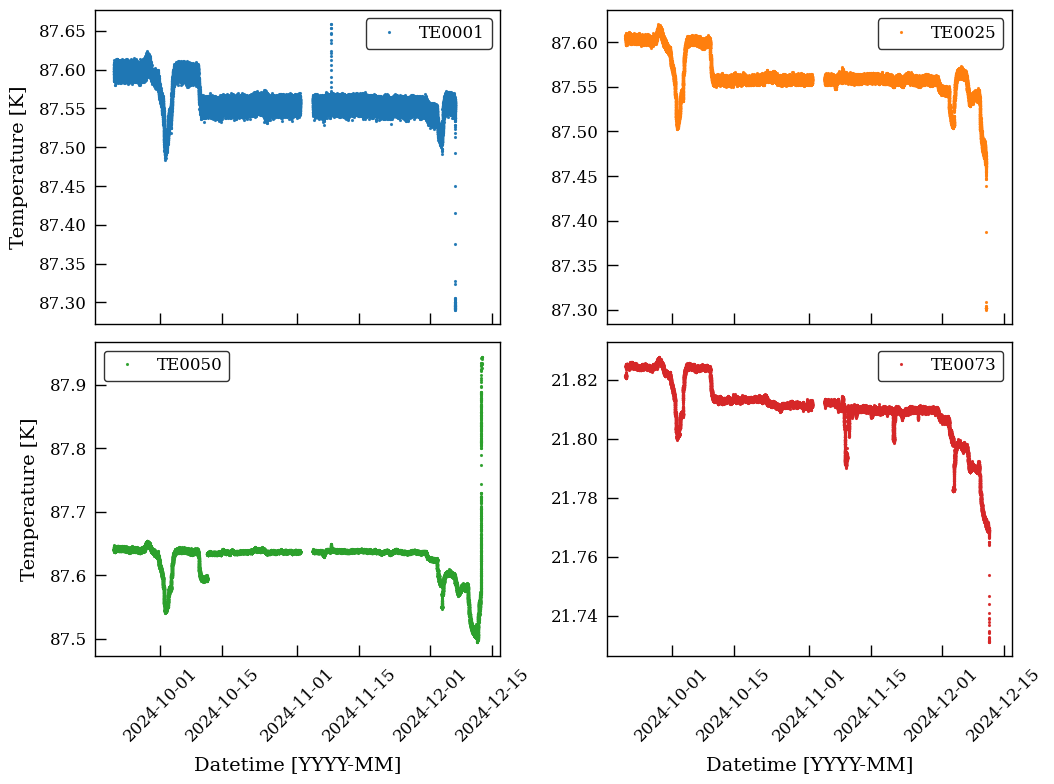

In [48]:
fig, ax = plt.subplots(2,2,figsize=(10.6, 8), sharex=True, sharey=False)
ax = ax.flatten()

ax[0].plot(dataset.data.index.values, (dataset.data["TE0001"]/mux1.data).values, ".", label="TE0001", color="tab:blue", alpha=0.9)
ax[1].plot(dataset.data.index.values, (dataset.data["TE0025"]/mux2.data).values, ".", label="TE0025", color="tab:orange", alpha=0.9)
ax[2].plot(dataset.data.index.values, (dataset.data["TE0050"]/mux3.data).values, ".", label="TE0050", color="tab:green", alpha=0.9)
ax[3].plot(dataset.data.index.values, (dataset.data["TE0073"]/mux4.data).values, ".", label="TE0073", color="tab:red", alpha=0.9)

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()

ax[2].tick_params(axis='x', rotation=45)
ax[3].tick_params(axis='x', rotation=45);

ax[0].set_ylabel("Temperature [K]")
ax[2].set_ylabel("Temperature [K]")
ax[2].set_xlabel("Datetime [YYYY-MM]")
ax[3].set_xlabel("Datetime [YYYY-MM]")
fig.tight_layout()

In [49]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 10, 15)) & (dataset.data.index < datetime.datetime(2024, 11, 29)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

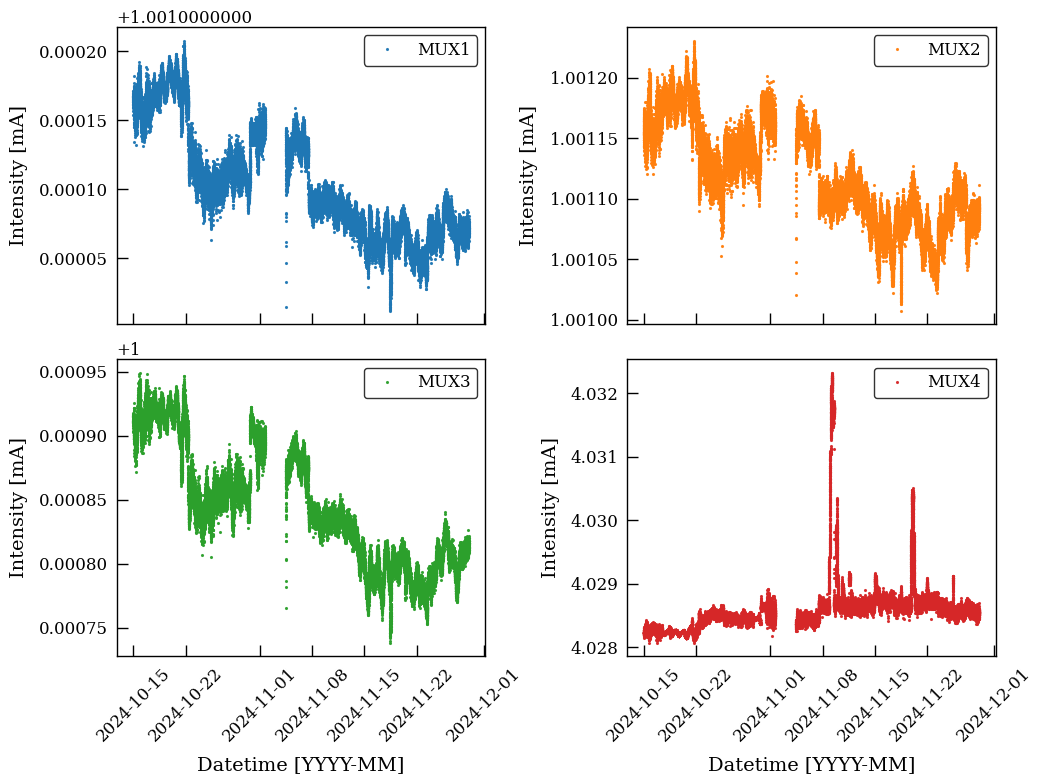

In [50]:
sensor = sensorClasses.Sensor(dataset=dataset, id=39630)
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

mux1.data = mux1.data.loc[(mux1.data>1)&(mux1.data<1.0014)]
mux2.data = mux2.data.loc[(mux2.data>1)&(mux2.data<1.0014)]
mux3.data = mux3.data.loc[(mux3.data>1)&(mux3.data<1.1)]
mux4.data = mux4.data.loc[(mux4.data>4)&(mux4.data<4.05)]
ambient = sensorClasses.Sensor(dataset=dataset, id=1037)
fig, ax = plt.subplots(2,2,figsize=(10.6, 8), sharex=True, sharey=False)
ax = ax.flatten()
ax[0].plot(mux1.data.index.values, mux1.data.values, ".", label="MUX1", color="tab:blue", alpha=0.9)
ax[1].plot(mux2.data.index.values, mux2.data.values, ".", label="MUX2", color="tab:orange", alpha=0.9)
ax[2].plot(mux3.data.index.values, mux3.data.values, ".", label="MUX3", color="tab:green", alpha=0.9)
ax[3].plot(mux4.data.index.values, mux4.data.values, ".", label="MUX4", color="tab:red", alpha=0.9)
# ax.plot(mux3.data.index.values, 1e6*(mux3.data.values - mux3.data.mean()) - 50, ".", label="MUX3", color="tab:green", alpha=0.9)
# ax.plot(mux4.data.index.values, 1e6*(4/mux4.data.values - 4/mux4.data.mean()) - 100, ".", label="MUX4", color="tab:red", alpha=0.9)
ax[2].tick_params(axis='x', rotation=45)
ax[3].tick_params(axis='x', rotation=45)
# ax2 = ax.twinx()
# ax2.set_ylabel("Ambient Temperature [ºC]")
# ax2.plot(ambient.data.index.values, ambient.data.values, ".", markersize=1.5, label="Ambient Temperature", color="black", alpha=0.2)
ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()
ax[0].set_ylabel("Intensity [mA]")
ax[1].set_ylabel("Intensity [mA]")
ax[2].set_ylabel("Intensity [mA]")
ax[3].set_ylabel("Intensity [mA]")
ax[2].set_xlabel("Datetime [YYYY-MM]")
ax[3].set_xlabel("Datetime [YYYY-MM]")
fig.tight_layout()

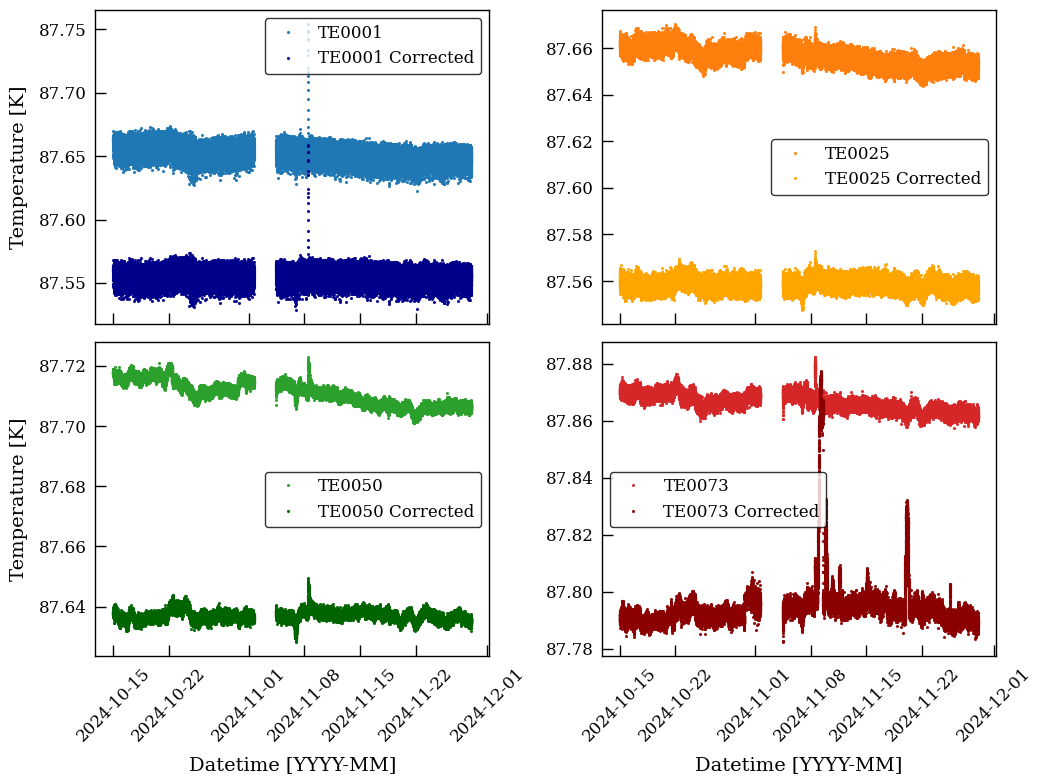

In [51]:
fig, ax = plt.subplots(2,2,figsize=(10.6, 8), sharex=True, sharey=False)
ax = ax.flatten()

mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

ax[0].plot(dataset.data.index.values, dataset.data["TE0001"].values, ".", label="TE0001", color="tab:blue", alpha=0.9)
ax[1].plot(dataset.data.index.values, dataset.data["TE0025"].values, ".", label="TE0025", color="tab:orange", alpha=0.9)
ax[2].plot(dataset.data.index.values, dataset.data["TE0050"].values, ".", label="TE0050", color="tab:green", alpha=0.9)
ax[3].plot(dataset.data.index.values, dataset.data["TE0073"].values, ".", label="TE0073", color="tab:red", alpha=0.9)

ax[0].plot(dataset.data.index.values, (dataset.data["TE0001"]/mux1.data).values, ".", label="TE0001 Corrected", color="darkblue", alpha=0.9)
ax[1].plot(dataset.data.index.values, (dataset.data["TE0025"]/mux2.data).values, ".", label="TE0025 Corrected", color="orange", alpha=0.9)
ax[2].plot(dataset.data.index.values, (dataset.data["TE0050"]/mux3.data).values, ".", label="TE0050 Corrected", color="darkgreen", alpha=0.9)
ax[3].plot(dataset.data.index.values, (dataset.data["TE0073"]*mux4.data/4).values - 0.7, ".", label="TE0073 Corrected", color="darkred", alpha=0.9)

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()

ax[2].tick_params(axis='x', rotation=45)
ax[3].tick_params(axis='x', rotation=45);

ax[0].set_ylabel("Temperature [K]")
ax[2].set_ylabel("Temperature [K]")
ax[2].set_xlabel("Datetime [YYYY-MM]")
ax[3].set_xlabel("Datetime [YYYY-MM]")
fig.tight_layout()

# Effect room temperature on MUX current

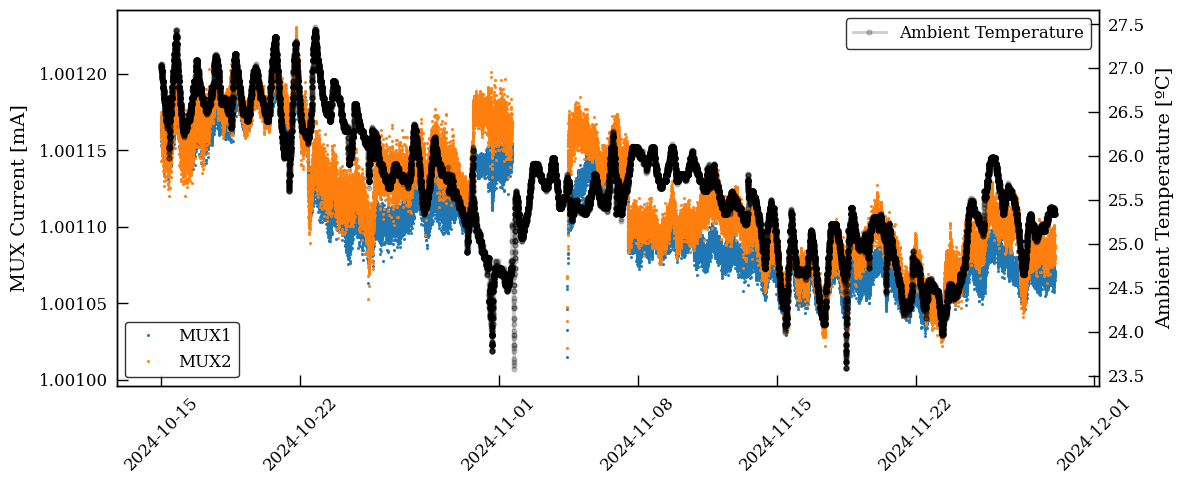

In [52]:
sensor = sensorClasses.Sensor(dataset=dataset, id=39630)
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

mux1.data = mux1.data.loc[(mux1.data>1)&(mux1.data<1.0014)]
mux2.data = mux2.data.loc[(mux2.data>1)&(mux2.data<1.0014)]
mux3.data = mux3.data.loc[(mux3.data>1)&(mux3.data<1.1)]
mux4.data = mux4.data.loc[(mux4.data>4)&(mux4.data<4.05)]
ambient = sensorClasses.Sensor(dataset=dataset, id=1037)
ambient.data = ambient.data.dropna()
ambient.data = ambient.data.loc[(ambient.data>23.5)]
fig, ax = plt.subplots(1,1,figsize=(12, 5))
ax.set_ylabel("MUX Current [mA]")
ax.plot(mux1.data.index.values, mux1.data.values, ".", label="MUX1", color="tab:blue", alpha=0.9)
ax.plot(mux2.data.index.values, mux2.data.values, ".", label="MUX2", color="tab:orange", alpha=0.9)
# ax.plot(mux3.data.index.values, mux3.data.values, ".", label="MUX3", color="tab:green", alpha=0.9)
# ax.plot(mux3.data.index.values, 1e6*(mux3.data.values - mux3.data.mean()) - 50, ".", label="MUX3", color="tab:green", alpha=0.9)
# ax.plot(mux4.data.index.values, 1e6*(4/mux4.data.values - 4/mux4.data.mean()) - 100, ".", label="MUX4", color="tab:red", alpha=0.9)
ax.tick_params(axis='x', rotation=45)
ax2 = ax.twinx()
ax2.set_ylabel("Ambient Temperature [ºC]")
ax2.plot(ambient.data.index.values, ambient.data.values, "-o", markersize=3.5, label="Ambient Temperature", color="black", alpha=0.2)
ax.legend(loc="lower left")
ax2.legend(loc="upper right")
fig.tight_layout()

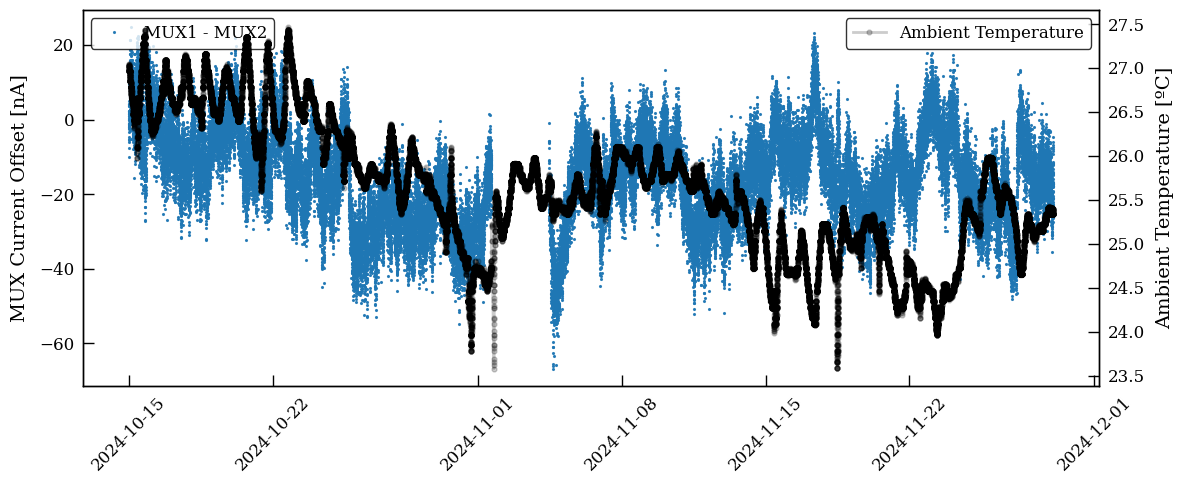

In [53]:
sensor = sensorClasses.Sensor(dataset=dataset, id=39630)
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

mux1.data = mux1.data.loc[(mux1.data>1)&(mux1.data<1.0014)]
mux2.data = mux2.data.loc[(mux2.data>1)&(mux2.data<1.0014)]
mux3.data = mux3.data.loc[(mux3.data>1)&(mux3.data<1.1)]
mux4.data = mux4.data.loc[(mux4.data>4)&(mux4.data<4.05)]
ambient = sensorClasses.Sensor(dataset=dataset, id=1037)
ambient.data = ambient.data.dropna()
ambient.data = ambient.data.loc[(ambient.data>23.5)]
fig, ax = plt.subplots(1,1,figsize=(12, 5))
ax.set_ylabel("MUX Current Offset [nA]")
ax.plot(mux1.data.index.values, 1e6*(mux1.data - mux2.data).values, ".", label="MUX1 - MUX2", color="tab:blue", alpha=0.9)
# ax.plot(mux2.data.index.values, mux2.data.values, ".", label="MUX2", color="tab:orange", alpha=0.9)
# ax.plot(mux3.data.index.values, mux3.data.values, ".", label="MUX3", color="tab:green", alpha=0.9)
# ax.plot(mux3.data.index.values, 1e6*(mux3.data.values - mux3.data.mean()) - 50, ".", label="MUX3", color="tab:green", alpha=0.9)
# ax.plot(mux4.data.index.values, 1e6*(4/mux4.data.values - 4/mux4.data.mean()) - 100, ".", label="MUX4", color="tab:red", alpha=0.9)
ax.tick_params(axis='x', rotation=45)
ax2 = ax.twinx()
ax2.set_ylabel("Ambient Temperature [ºC]")
ax2.plot(ambient.data.index.values, ambient.data.values, "-o", markersize=3.5, label="Ambient Temperature", color="black", alpha=0.2)
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
fig.tight_layout()

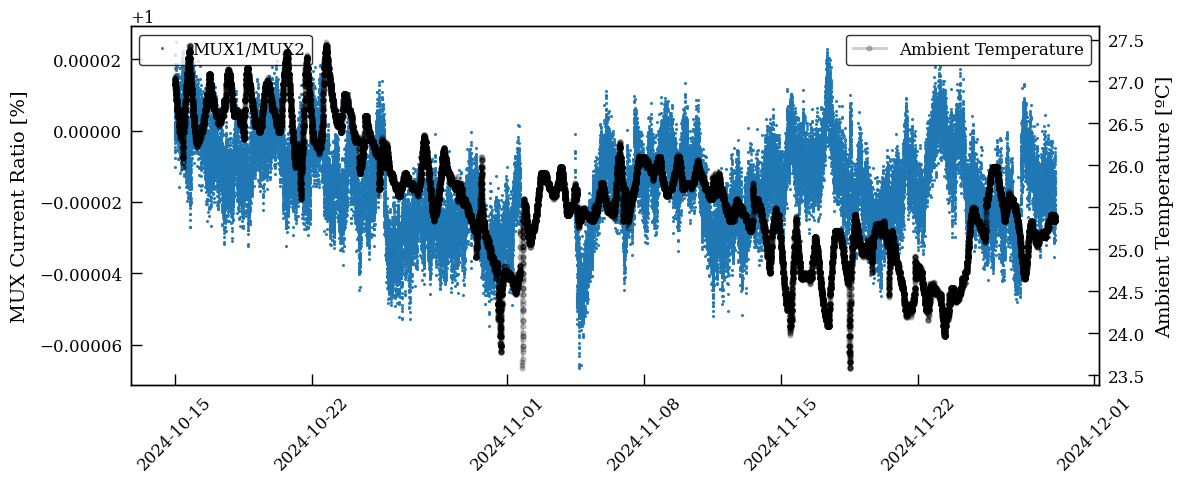

In [54]:
sensor = sensorClasses.Sensor(dataset=dataset, id=39630)
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

mux1.data = mux1.data.loc[(mux1.data>1)&(mux1.data<1.0014)]
mux2.data = mux2.data.loc[(mux2.data>1)&(mux2.data<1.0014)]
mux3.data = mux3.data.loc[(mux3.data>1)&(mux3.data<1.1)]
mux4.data = mux4.data.loc[(mux4.data>4)&(mux4.data<4.05)]
ambient = sensorClasses.Sensor(dataset=dataset, id=1037)
ambient.data = ambient.data.dropna()
ambient.data = ambient.data.loc[(ambient.data>23.5)]
fig, ax = plt.subplots(1,1,figsize=(12, 5))
ax.set_ylabel("MUX Current Ratio [%]")
ax.plot(mux1.data.index.values, (mux1.data/mux2.data).values, ".", label="MUX1/MUX2", color="tab:blue", alpha=0.9)
# ax.plot(mux2.data.index.values, mux2.data.values, ".", label="MUX2", color="tab:orange", alpha=0.9)
# ax.plot(mux3.data.index.values, mux3.data.values, ".", label="MUX3", color="tab:green", alpha=0.9)
# ax.plot(mux3.data.index.values, 1e6*(mux3.data.values - mux3.data.mean()) - 50, ".", label="MUX3", color="tab:green", alpha=0.9)
# ax.plot(mux4.data.index.values, 1e6*(4/mux4.data.values - 4/mux4.data.mean()) - 100, ".", label="MUX4", color="tab:red", alpha=0.9)
ax.tick_params(axis='x', rotation=45)
ax2 = ax.twinx()
ax2.set_ylabel("Ambient Temperature [ºC]")
ax2.plot(ambient.data.index.values, ambient.data.values, "-o", markersize=3.5, label="Ambient Temperature", color="black", alpha=0.2)
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
fig.tight_layout()

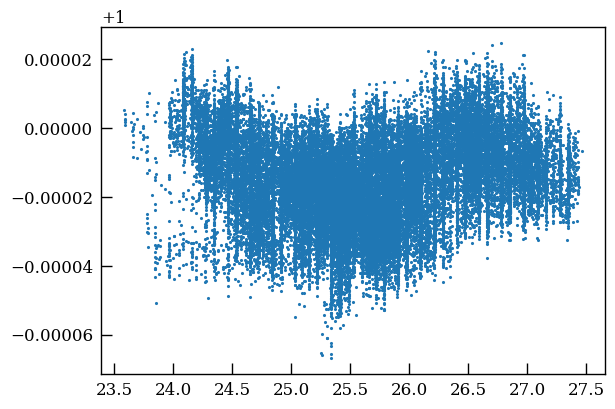

In [55]:
common_idx = ambient.data.index.intersection(mux1.data.index).intersection(mux2.data.index)
plt.plot(ambient.data.loc[common_idx].values, (mux1.data.loc[common_idx] / mux2.data.loc[common_idx]).values, ".")

# Effect of room temperature on temperature data

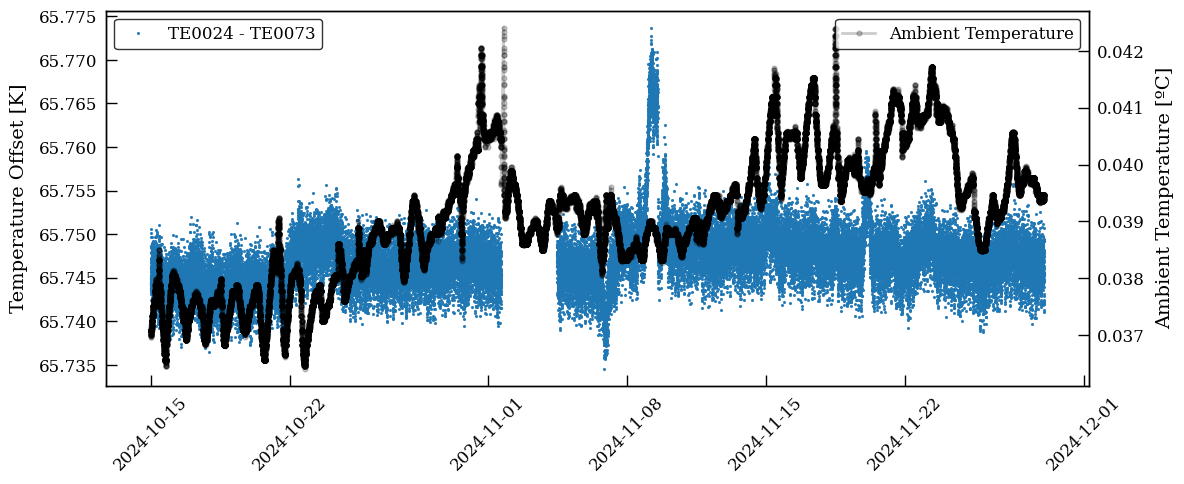

In [25]:
sensor = sensorClasses.Sensor(dataset=dataset, id=39630)
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

mux1.data = mux1.data.loc[(mux1.data>1)&(mux1.data<1.0014)]
mux2.data = mux2.data.loc[(mux2.data>1)&(mux2.data<1.0014)]
mux3.data = mux3.data.loc[(mux3.data>1)&(mux3.data<1.1)]
mux4.data = mux4.data.loc[(mux4.data>4)&(mux4.data<4.05)]
ambient = sensorClasses.Sensor(dataset=dataset, id=1037)
ambient.data = ambient.data.dropna()
ambient.data = ambient.data.loc[(ambient.data>23.5)]
dataset.data["TE0024"] = dataset.data["TE0024"].loc[(dataset.data["TE0024"] > 87) & (dataset.data["TE0024"] < 88)]
fig, ax = plt.subplots(1,1,figsize=(12, 5))
ax.set_ylabel("Temperature Offset [K]")
# ax.plot(dataset.data.index.values, (dataset.data["TE0024"]- dataset.data["TE0025"]).values, ".", label="TE0024 - TE0025", color="tab:blue", alpha=0.9)
# ax.plot(dataset.data.index.values, (dataset.data["TE0024"]/mux1.data - dataset.data["TE0025"]/mux2.data).values, ".", label="TE0024 - TE0025", color="tab:blue", alpha=0.9)
# ax.plot(dataset.data.index.values, (dataset.data["TE0024"]/mux1.data - dataset.data["TE0050"]/mux3.data).values, ".", label="TE0024 - TE0050", color="tab:blue", alpha=0.9)
ax.plot(dataset.data.index.values, (dataset.data["TE0024"]/mux1.data - dataset.data["TE0073"]/mux4.data).values, ".", label="TE0024 - TE0073", color="tab:blue", alpha=0.9)
# ax.plot(dataset.data.index.values, (dataset.data["TE0045"]/mux2.data).values, ".", label="TE0045", color="tab:orange", alpha=0.9)
# ax.plot(mux2.data.index.values, mux2.data.values, ".", label="MUX2", color="tab:orange", alpha=0.9)
# ax.plot(mux3.data.index.values, mux3.data.values, ".", label="MUX3", color="tab:green", alpha=0.9)
# ax.plot(mux3.data.index.values, 1e6*(mux3.data.values - mux3.data.mean()) - 50, ".", label="MUX3", color="tab:green", alpha=0.9)
# ax.plot(mux4.data.index.values, 1e6*(4/mux4.data.values - 4/mux4.data.mean()) - 100, ".", label="MUX4", color="tab:red", alpha=0.9)
# ax.set_ylim(87.565, 87.580)
ax.tick_params(axis='x', rotation=45)
ax2 = ax.twinx()
ax2.set_ylabel("Ambient Temperature [ºC]")
ax2.plot(ambient.data.index.values, 1/ambient.data.values, "-o", markersize=3.5, label="Ambient Temperature", color="black", alpha=0.2)
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
fig.tight_layout()

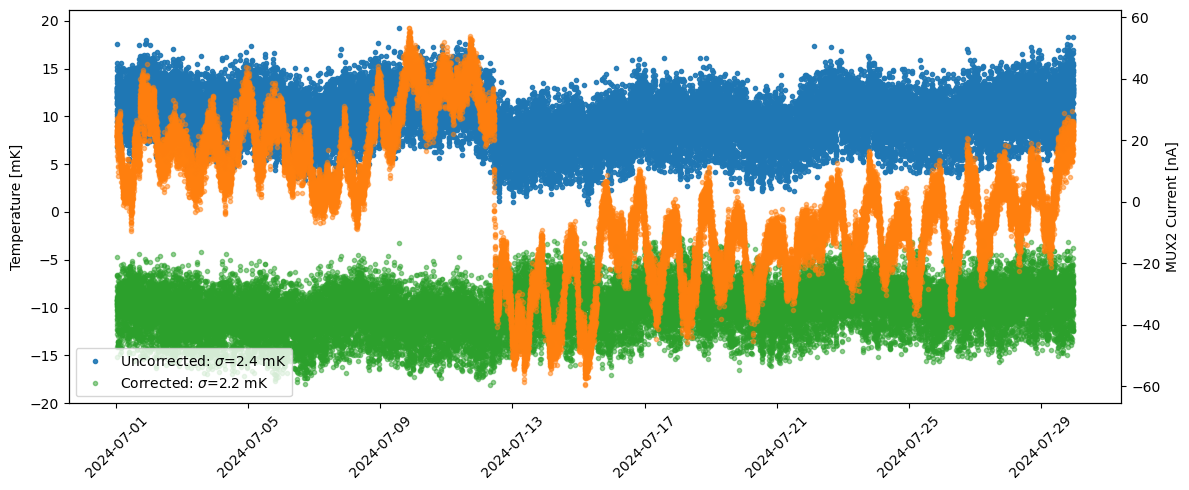

In [18]:
sensor = sensorClasses.Sensor(dataset=dataset, id=39630)
fig, ax = plt.subplots(1,1,figsize=(12, 5))
ax.set_ylabel("Temperature [mK]")
ax.plot(sensor.data.index.values, 1e3*(sensor.data.values - sensor.data.mean()) + 10,
        ".", label=fr"Uncorrected: $\sigma$={1e3*sensor.data.std():.1f} mK", color="tab:blue", alpha=0.9)
ax.tick_params(axis='x', rotation=45)
sensor.muxEqualization()
# print(sensor.is_mux_equalized)
ax.plot(sensor.data.index.values, 1e3*(sensor.data.values - sensor.data.mean()) - 10,
        ".", label=fr"Corrected: $\sigma$={1e3*sensor.data.std():.1f} mK", color="tab:green", alpha=0.5)
ax.legend(loc="lower left")
ax2 = ax.twinx()
ax2.plot(mux2.data.index.values, 1e6*(mux2.data.values - mux2.data.mean()), ".", label="MUX2 Current", color="tab:orange", alpha=0.5)
ax2.set_ylabel("MUX2 Current [nA]")
fig.tight_layout()

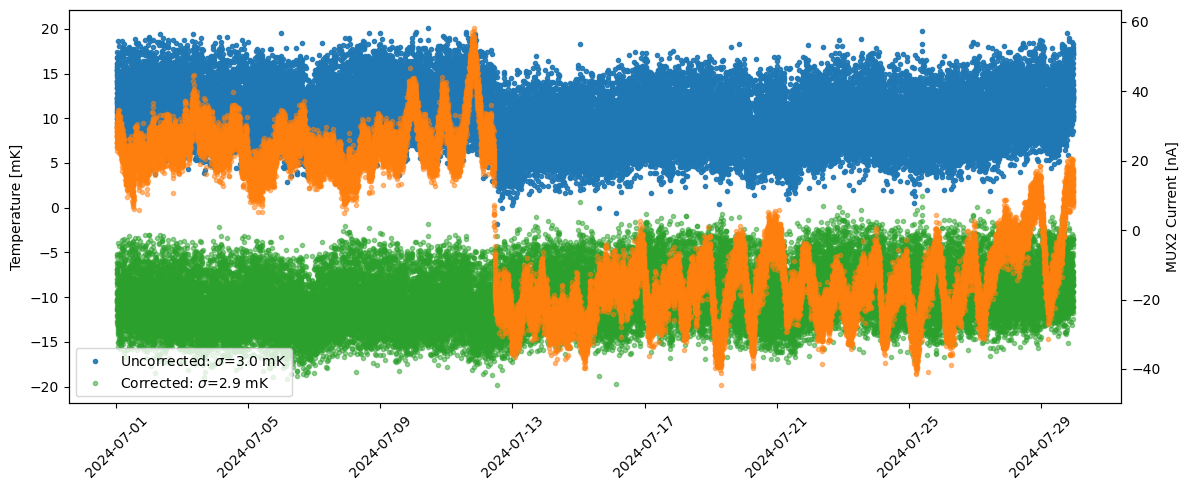

In [8]:
sensor = sensorClasses.Sensor(dataset=dataset, id=40012)
fig, ax = plt.subplots(1,1,figsize=(12, 5))
ax.set_ylabel("Temperature [mK]")
ax.plot(sensor.data.index.values, 1e3*(sensor.data.values - sensor.data.mean()) + 10,
        ".", label=fr"Uncorrected: $\sigma$={1e3*sensor.data.std():.1f} mK", color="tab:blue", alpha=0.9)
ax.tick_params(axis='x', rotation=45)
sensor.muxEqualization()
# print(sensor.is_mux_equalized)
ax.plot(sensor.data.index.values, 1e3*(sensor.data.values - sensor.data.mean()) - 10,
        ".", label=fr"Corrected: $\sigma$={1e3*sensor.data.std():.1f} mK", color="tab:green", alpha=0.5)
ax.legend(loc="lower left")
ax2 = ax.twinx()
ax2.plot(mux3.data.index.values, 1e6*(mux3.data.values - mux3.data.mean()), ".", label="MUX2 Current", color="tab:orange", alpha=0.5)
ax2.set_ylabel("MUX2 Current [nA]")
fig.tight_layout()

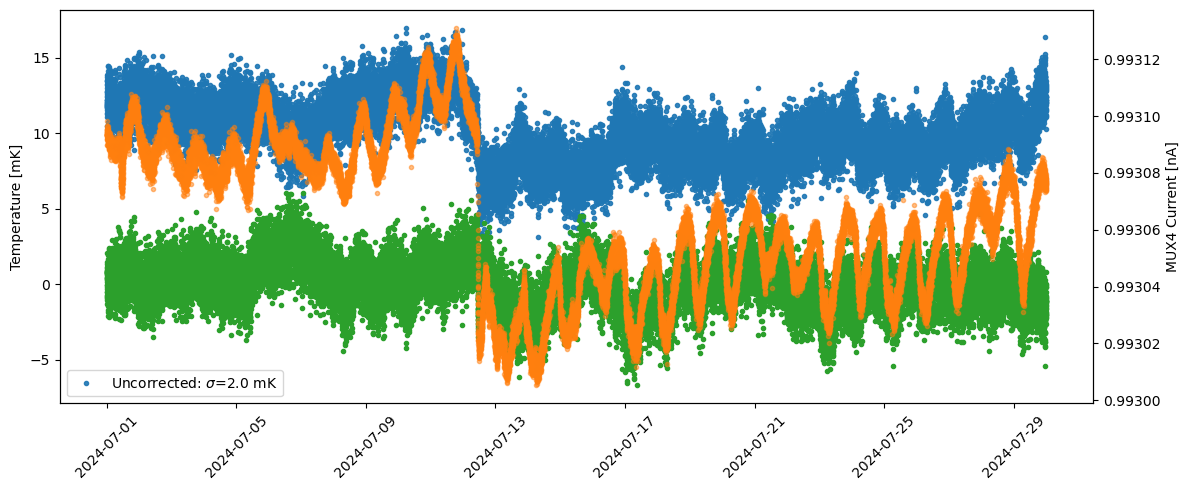

In [ ]:
sensor = sensorClasses.Sensor(dataset=dataset, id=37127)
fig, ax = plt.subplots(1,1,figsize=(12, 5))
ax.set_ylabel("Temperature [mK]")
ax.plot(sensor.data.index.values, 1e3*(sensor.data.values - sensor.data.mean()) + 10,
        ".", label=fr"Uncorrected: $\sigma$={1e3*sensor.data.std():.1f} mK", color="tab:blue", alpha=0.9)
# ax.plot(sensor.data.index.values, sensor.data.values,
#         ".", label=fr"Uncorrected: $\sigma$={1e3*sensor.data.std():.1f} mK", color="tab:blue", alpha=0.9)
ax.plot(sensor.data.index.values, -1e3*((sensor.data/(4/mux4.data)).values - (sensor.data/(4/mux4.data)).mean()), ".", color="tab:green")
ax.tick_params(axis='x', rotation=45)
sensor.muxEqualization()
# print(sensor.is_mux_equalized)
# ax.plot(sensor.data.index.values, 1e3*(sensor.data.values - sensor.data.mean()) - 10,
#         ".", label=fr"Corrected: $\sigma$={1e3*sensor.data.std():.1f} mK", color="tab:green", alpha=0.5)
# ax.plot(sensor.data.index.values, -sensor.data.values + 0.2,
#         ".", label=fr"Corrected: $\sigma$={1e3*sensor.data.std():.1f} mK", color="tab:green", alpha=0.5)
ax.legend(loc="lower left")
ax2 = ax.twinx()
ax2.plot(mux4.data.index.values, 4/(mux4.data).values, ".", label="MUX4 Current", color="tab:orange", alpha=0.5)
# ax2.plot(mux4.data.index.values, (-mux4.data*0.24881922 + 2).values, ".", label="MUX4 Current", color="tab:orange", alpha=0.5)
ax2.set_ylabel("MUX4 Current [nA]")
fig.tight_layout()

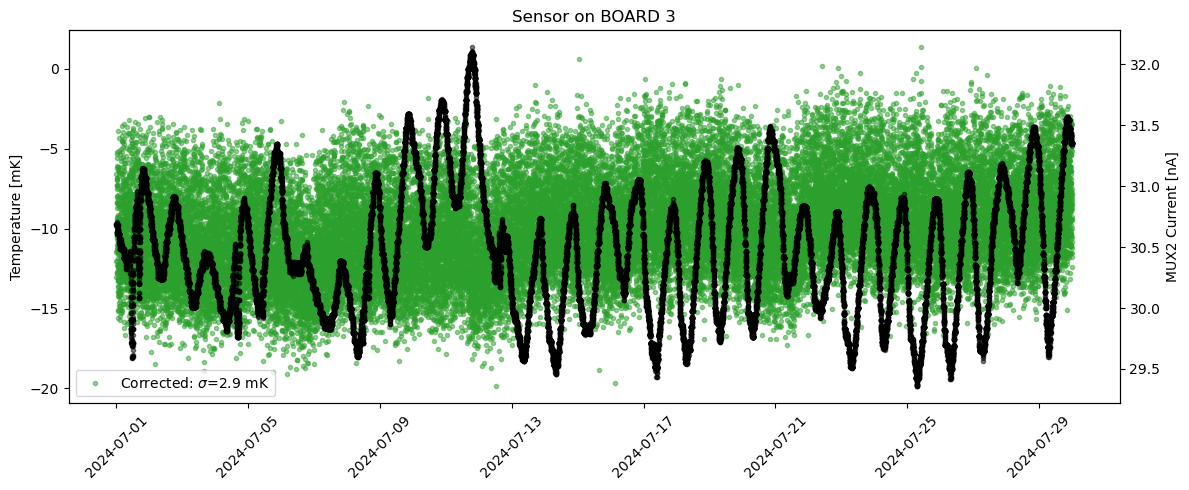

In [22]:
sensor = sensorClasses.Sensor(dataset=dataset, id=40012)
fig, ax = plt.subplots(1,1,figsize=(12, 5))
ax.set_ylabel("Temperature [mK]")
ax.tick_params(axis='x', rotation=45)
sensor.muxEqualization()
# print(sensor.is_mux_equalized)
ax.plot(sensor.data.index.values, 1e3*(sensor.data.values - sensor.data.mean()) - 10,
        ".", label=fr"Corrected: $\sigma$={1e3*sensor.data.std():.1f} mK", color="tab:green", alpha=0.5)
ax.legend(loc="lower left")
ax.set_title("Sensor on BOARD 3")
ax2 = ax.twinx()
ax2.plot(ambient.data.index.values, ambient.data.values - line(ambient.data.index.values.astype(float), *popt), ".", label="Ambient Temperature", color="black", alpha=0.5)
ax2.set_ylabel("MUX2 Current [nA]")
fig.tight_layout()

No handles with labels found to put in legend.


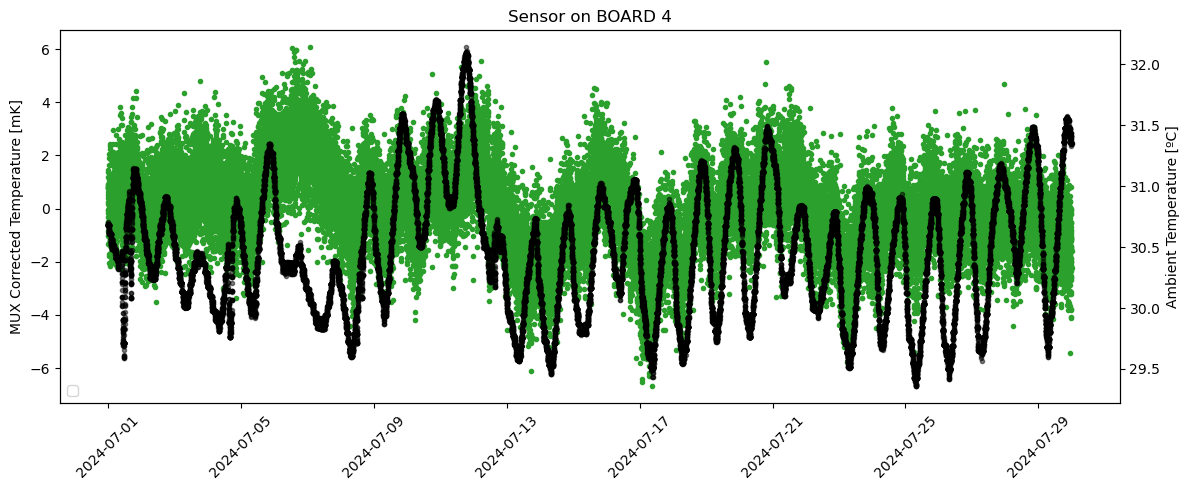

In [23]:
from scipy.optimize import curve_fit
sensor = sensorClasses.Sensor(dataset=dataset, id=37127)
fig, ax = plt.subplots(1,1,figsize=(12, 5))
ax.set_ylabel("MUX Corrected Temperature [mK]")
ax.plot(sensor.data.index.values, -1e3*((sensor.data/(4/mux4.data)).values - (sensor.data/(4/mux4.data)).mean()), ".", color="tab:green")
ax.tick_params(axis='x', rotation=45)
ax.legend(loc="lower left")
ax.set_title("Sensor on BOARD 4")
ax2 = ax.twinx()
# ax2.plot(ambient.data.index.values, (ambient.data.values - ambient.data.mean()), ".", label="Ambient Temperature", color="black", alpha=0.5)

def line(x, m, b):
    return m * x + b

popt, pcov = curve_fit(line, ambient.data.dropna().index.values.astype(float), ambient.data.dropna().values - ambient.data.mean())
# ax2.plot(ambient.data.index.values, line(ambient.data.index.values.astype(float), *popt), label="Ambient Temperature Fit", color="black", alpha=0.5)
ax2.plot(ambient.data.index.values, ambient.data.values - line(ambient.data.index.values.astype(float), *popt), ".", label="Ambient Temperature", color="black", alpha=0.5)
ax2.set_ylabel("Ambient Temperature [ºC]")
fig.tight_layout()

<ErrorbarContainer object of 3 artists>

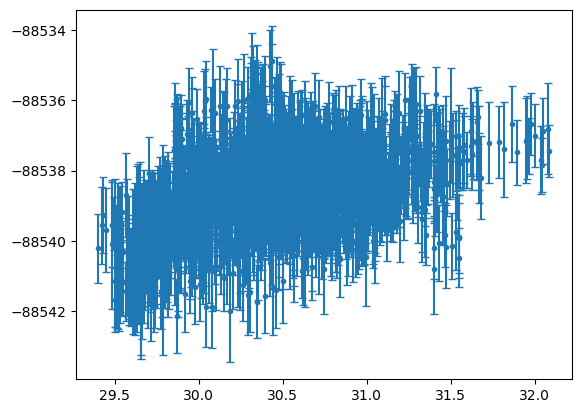

In [25]:
fig, axes = plt.subplots(1,1)
axes.errorbar((ambient.data - line(ambient.data.index.values.astype(float), *popt)).resample("30min").mean().values,
          1e3*((sensor.data/(-4/mux4.data)).resample("30min").mean().values),
          yerr=1e3*((sensor.data/(-4/mux4.data)).resample("30min").std().values),
        #   xerr=1e3*((ambient.data - line(ambient.data.index.values.astype(float), *popt)).resample("30min").std().values),
          fmt=".", capsize=3)

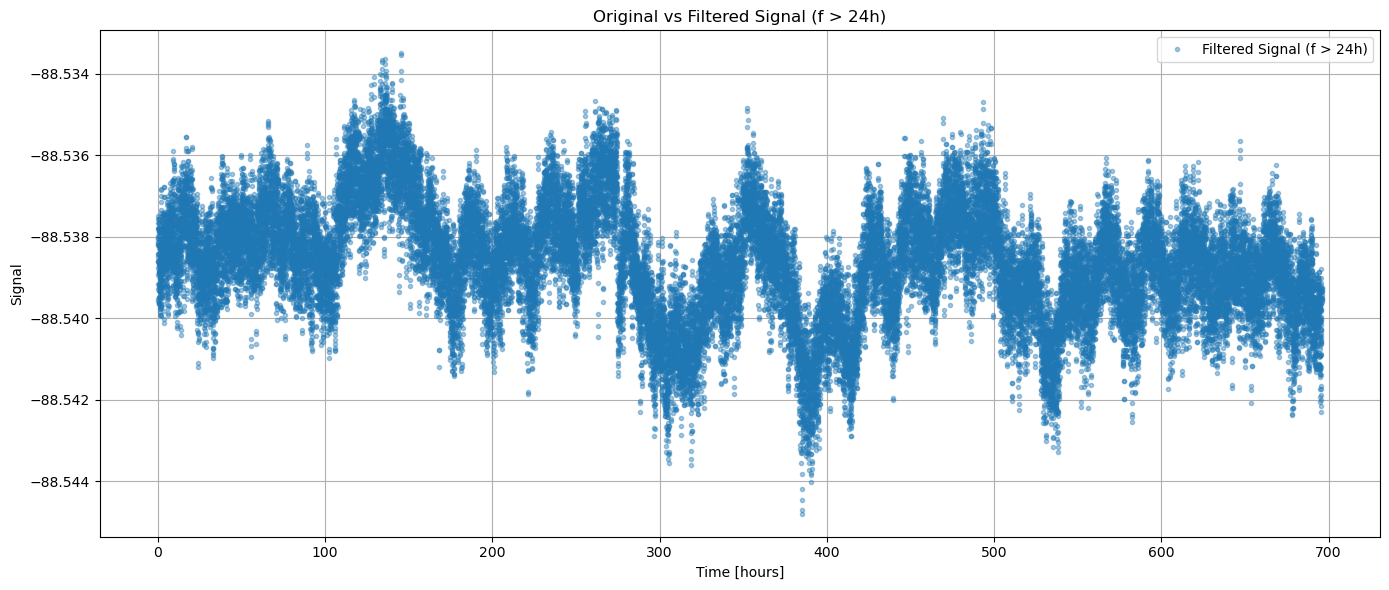

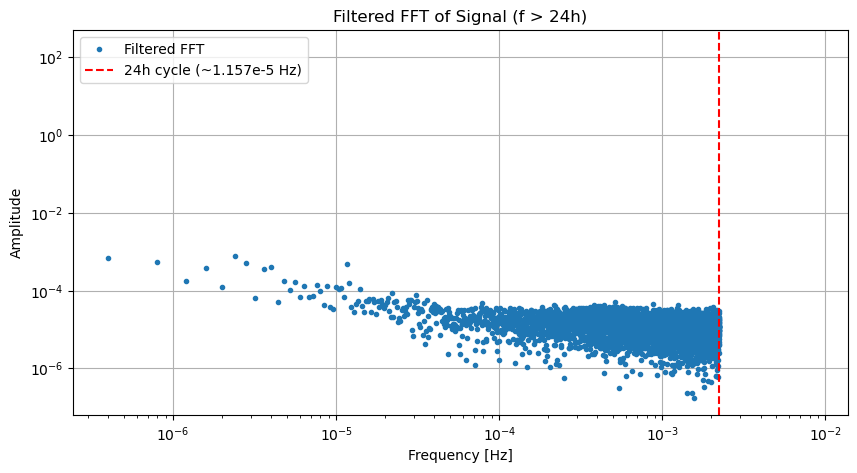

In [36]:
from scipy.fft import fft, ifft, fftfreq
import numpy as np
import matplotlib.pyplot as plt

# Clean data
clean_data = (sensor.data / (-4 / mux4.data)).dropna().values
N = len(clean_data)
T = (ambient.data.index[1] - ambient.data.index[0]).total_seconds()

# Compute FFT
yf = fft(clean_data)
xf = fftfreq(N, T)

# 24-hour cycle frequency in Hz
f_24h = 1 / (0.125 * 3600)  # ≈ 1.157e-5 Hz
# f_24h = 5e-5 # ≈ 1.157e-5 Hz

# Filter: zero out frequencies below 24h frequency
mask = np.abs(xf) > f_24h
yf_filtered = yf.copy()
yf_filtered[mask] = 0

# Inverse FFT to get the filtered signal
reconstructed = ifft(yf_filtered).real  # Keep real part

# Plot original vs filtered signal
time_axis = np.arange(N) * T / 3600  # Time in hours

plt.figure(figsize=(14, 6))
# plt.plot(time_axis, clean_data - np.mean(clean_data), ".", label='Original Signal', alpha=0.5)
plt.plot(time_axis, reconstructed, ".", label='Filtered Signal (f > 24h)', linewidth=2, alpha=0.4)
plt.xlabel('Time [hours]')
plt.ylabel('Signal')
plt.title('Original vs Filtered Signal (f > 24h)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot the FFT of the filtered signal
yf_filtered_abs = np.abs(yf_filtered)
plt.figure(figsize=(10, 5))
plt.plot(xf[:N // 2], 2.0 / N * yf_filtered_abs[:N // 2], ".", label="Filtered FFT")
plt.axvline(x=f_24h, color='red', linestyle='--', label='24h cycle (~1.157e-5 Hz)')
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.yscale("log")
plt.xscale("log")
plt.title("Filtered FFT of Signal (f > 24h)")
plt.grid(True)
plt.legend()
plt.show()


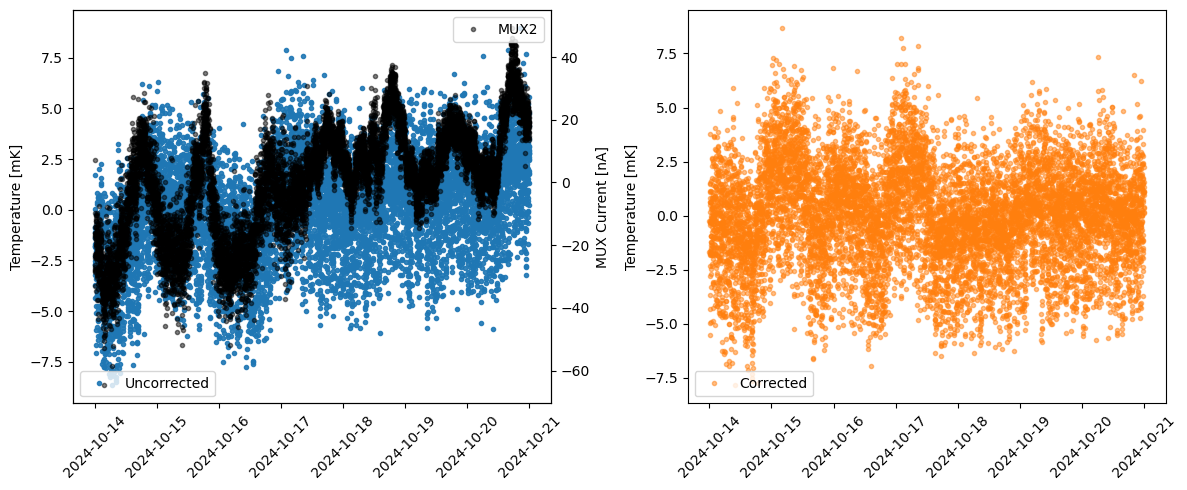

In [11]:
sensor = sensorClasses.Sensor(dataset=dataset, id=39630)
mux = muxClasses.MUX(dataset=dataset, boardNumber=2)
fig, ax = plt.subplots(1,2,figsize=(12, 5))
ax[0].set_ylabel("Temperature [mK]")
ax[0].plot(sensor.data.index.values, 1e3*(sensor.data.values - sensor.data.mean()), ".", label="Uncorrected", color="tab:blue", alpha=0.9)
ax[0].tick_params(axis='x', rotation=45)
ax[0].legend(loc="lower left")
ax2 = ax[0].twinx()
ax2.set_ylabel("MUX Current [nA]")
ax2.plot(mux.data.index.values, 1e6*(mux.data.values - mux.data.mean()), ".", label="MUX2", color="black", alpha=0.5)
ax2.legend(loc="upper right")
sensor.muxCorrection()
ax[1].plot(sensor.data.index.values, 1e3*(sensor.data.values - sensor.data.mean()), ".", label="Corrected", color="tab:orange", alpha=0.5)
ax[1].set_ylabel("Temperature [mK]")
ax[1].tick_params(axis='x', rotation=45)
ax[1].legend(loc="lower left")
fig.tight_layout()

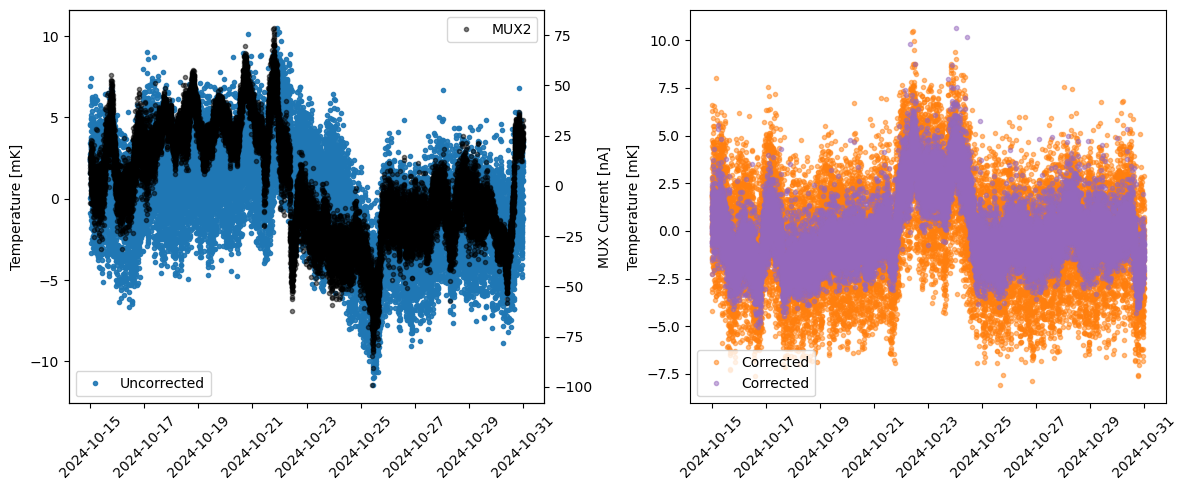

In [6]:
sensor = sensorClasses.Sensor(dataset=dataset, id=39630)
sensor2 = sensorClasses.Sensor(dataset=dataset, id=44127)
mux = muxClasses.MUX(dataset=dataset, boardNumber=2)
ambient = sensorClasses.Sensor(dataset=dataset, id=1017)
fig, ax = plt.subplots(1,2,figsize=(12, 5))
ax[0].set_ylabel("Temperature [mK]")
ax[0].plot(sensor.data.index.values, 1e3*(sensor.data.values - sensor.data.mean()), ".", label="Uncorrected", color="tab:blue", alpha=0.9)
ax[0].tick_params(axis='x', rotation=45)
ax[0].legend(loc="lower left")
ax2 = ax[0].twinx()
ax2.set_ylabel("MUX Current [nA]")
ax2.plot(mux.data.index.values, 1e6*(mux.data.values - mux.data.mean()), ".", label="MUX2", color="black", alpha=0.5)
ax2.legend(loc="upper right")
sensor.muxEqualization()
sensor2.muxEqualization()
ax[1].plot(sensor.data.index.values, 1e3*(sensor.data.values - sensor.data.mean()), ".", label="Corrected", color="tab:orange", alpha=0.5)
ax[1].plot(sensor2.data.index.values, 1e3*(sensor2.data.values - sensor2.data.mean()), ".", label="Corrected", color="tab:purple", alpha=0.5)
ax[1].set_ylabel("Temperature [mK]")
ax[1].tick_params(axis='x', rotation=45)
# ax3 = ax[1].twinx()
# ax3.set_ylabel("Ambient Temperature [ºC]")
# ax3.plot(ambient.data.index.values, ambient.data.values, "o", label="Ambient", color="tab:green", alpha=0.5)
ax[1].legend(loc="lower left")
fig.tight_layout()

# MUX Correction & MUX Equalization

In this section, the plots about the effect of the application of the MUX correction (division by measured intensity) and MUX equalization (sum of the equalization terms) are presented. Corrections are only available for the 96 HP-channels

In [46]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 9, 20)) & (dataset.data.index < datetime.datetime(2024, 9, 21)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [47]:
hp_res = {}
for id in [9001, 9002, 9003, 9004, 9005, 9006, 9007, 9008, 9009, 9010, 9011, 9012]:
    hp_res[id] = sensorClasses.Sensor(dataset=dataset, id=id)

ERROR: SensorID (9001) coordinates not found
ERROR: SensorID (9002) coordinates not found
ERROR: SensorID (9003) coordinates not found
ERROR: SensorID (9004) coordinates not found
ERROR: SensorID (9005) coordinates not found
ERROR: SensorID (9006) coordinates not found
ERROR: SensorID (9007) coordinates not found
ERROR: SensorID (9008) coordinates not found
ERROR: SensorID (9009) coordinates not found
ERROR: SensorID (9010) coordinates not found
ERROR: SensorID (9011) coordinates not found
ERROR: SensorID (9012) coordinates not found


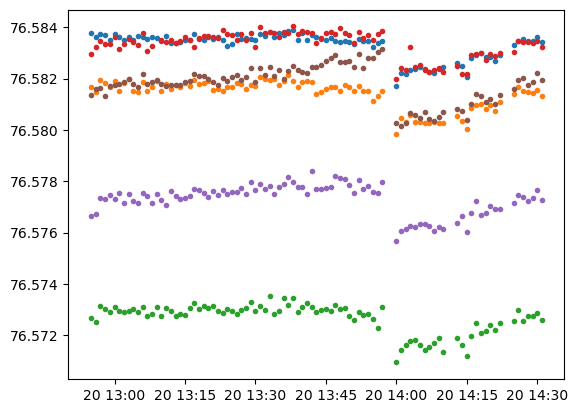

In [48]:
plt.plot(hp_res[9001].data.index.values, hp_res[9001].data.values, ".", label="V")
plt.plot(hp_res[9002].data.index.values, hp_res[9002].data.values, ".", label="V")
plt.plot(hp_res[9003].data.index.values, hp_res[9003].data.values, ".", label="V")
plt.plot(hp_res[9004].data.index.values, hp_res[9004].data.values, ".", label="V")
plt.plot(hp_res[9005].data.index.values, hp_res[9005].data.values, ".", label="V")
plt.plot(hp_res[9006].data.index.values, hp_res[9006].data.values, ".", label="V")

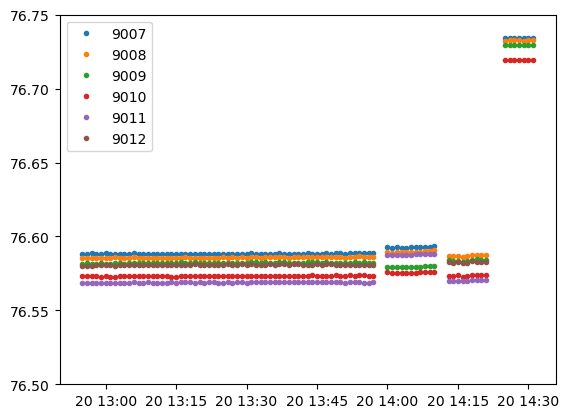

In [59]:
plt.plot(hp_res[9007].data.index.values, hp_res[9007].data.values, ".", label="9007")
plt.plot(hp_res[9008].data.index.values, hp_res[9008].data.values, ".", label="9008")
plt.plot(hp_res[9009].data.index.values, hp_res[9009].data.values, ".", label="9009")
plt.plot(hp_res[9010].data.index.values, hp_res[9010].data.values, ".", label="9010")
plt.plot(hp_res[9011].data.index.values, hp_res[9011].data.values, ".", label="9011")
plt.plot(hp_res[9012].data.index.values, hp_res[9012].data.values, ".", label="9012")
plt.ylim(76.5,76.75)
plt.legend()

In [49]:
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

                     IE_Card01          0
2024-09-20 12:55:00   1.001171  76.583793
2024-09-20 12:56:00   1.001175  76.583609
2024-09-20 12:57:00   1.001180  76.583731
2024-09-20 12:58:00   1.001180  76.583689
2024-09-20 12:59:00   1.001180  76.583516
...                        ...        ...
2024-09-20 14:27:00   1.001176  76.583547
2024-09-20 14:28:00   1.001183  76.583478
2024-09-20 14:29:00   1.001184  76.583455
2024-09-20 14:30:00   1.001184  76.583619
2024-09-20 14:31:00   1.001177  76.583441

[91 rows x 2 columns]


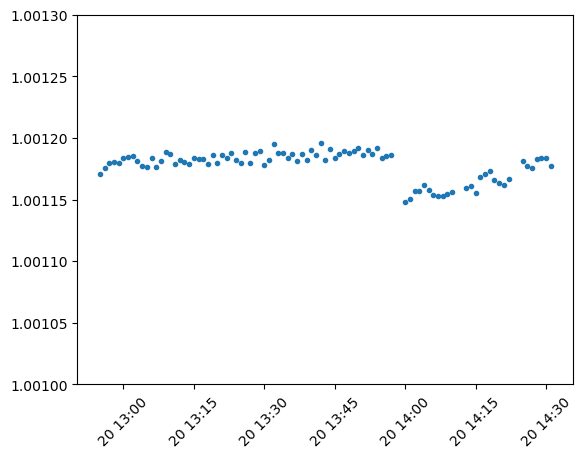

In [53]:
df = pd.concat([mux1.data, hp_res[9001].data], axis=1).dropna()
print(df)
plt.plot(df["IE_Card01"].index.values, df["IE_Card01"].values, ".", label="MUX")
plt.ylim(1.001, 1.0013)
plt.xticks(rotation=45);

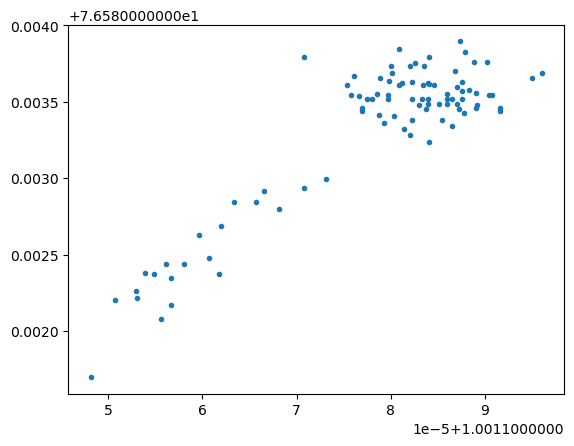

In [54]:
plt.plot(df["IE_Card01"].values, df[0].values, ".", label="MUX vs HP")